# Toy FQL Experiment Notebook

This notebook implements Flow Q-Learning (FQL), Flow-Based Actor-Critic (FBRAC), and FBRAC-Inner (TVL) algorithms for toy 2D experiments.

## Configuration


Modify the parameters in the next cell to customize the experiment.


In [1]:
import dotenv
%load_ext dotenv
%dotenv

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Experiment parameters
FLOW_STEPS = 25
NUM_LAYERS = 4
HIDDEN_DIM = 512
BC_EPOCHS = 2000
OFFLINE_EPOCHS = 100
LEARNING_RATE = 3e-4
BATCH_SIZE = 4096
NUM_PLOTS = 10
NUM_EVALS = 512
SAVE_DIR = 'toy_experiment'

epochs = BC_EPOCHS + OFFLINE_EPOCHS

# Which methods to run
RUN_FQL = True
RUN_FBRAC = True
RUN_TVL = True  # FBRAC-Inner

# Tasks to run: 'moons', 'two_spirals', 'swissroll', 'eight_gaussians'
TASKS = ['moons', 'two_spirals', 'swissroll']

# Alpha values (regularization/guidance coefficients)
ALPHAS = [5, 1, 0.5, 0.3]

# Target network settings
USE_TARGET_NETWORK = False
TAU = 0.005  # EMA rate for target network updates

# Dataset size
N_DATA = 10000

# Domain bounds
DOMAIN_MIN, DOMAIN_MAX = -4.0, 4.0

# Calculate derived parameters
EPOCHS = BC_EPOCHS + OFFLINE_EPOCHS
PLOT_STEP = EPOCHS // NUM_PLOTS if NUM_PLOTS > 0 else None

print(f"Configuration loaded:")
print(f"  Tasks: {TASKS}")
print(f"  Alphas: {ALPHAS}")
print(f"  Epochs: {EPOCHS} (BC: {BC_EPOCHS}, Offline: {OFFLINE_EPOCHS})")
print(f"  Flow steps: {FLOW_STEPS}")
print(f"  Network: {NUM_LAYERS} layers, {HIDDEN_DIM} hidden dim")
print(f"  Target network: {USE_TARGET_NETWORK} (tau={TAU})")


Configuration loaded:
  Tasks: ['moons', 'two_spirals', 'swissroll']
  Alphas: [5, 1, 0.5, 0.3]
  Epochs: 2100 (BC: 2000, Offline: 100)
  Flow steps: 25
  Network: 4 layers, 512 hidden dim
  Target network: False (tau=0.005)


In [3]:
import math
import os
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jrandom
import optax
import matplotlib.pyplot as plt
from functools import partial
from sklearn.utils import shuffle as util_shuffle
from sklearn.datasets import make_moons, make_swiss_roll
from tqdm import tqdm, trange

plt.rcParams['figure.figsize'] = [10, 8]
plt.rcParams['figure.dpi'] = 100

print("Imports complete!")


Imports complete!


In [15]:
task = "two_spirals"
DOMAIN_MIN, DOMAIN_MAX = -4.0, 4.0
DATASET_TYPE = task  

# ============================================================================
# 2. EXACT REFERENCE SAMPLERS (Returns Tuple: Data, Rewards)
# ============================================================================

def _sample_moons(n, noise=0.1):
    # 1. Generate using sklearn
    data, y = make_moons(n_samples=n, noise=noise)
    data = data.astype(np.float32)
    # 2. Transform coordinates: Scale * 2, Shift [-1, -0.2]
    data = data * 2.0 + np.array([-1.0, -0.2])

    # 3. Reference Reward: Class 1 (Bottom Moon) gets 1.0
    # y is (N,), make it (N, 1)
    rewards = (y > 0.5).astype(np.float32)[:, None]

    return np.clip(data, DOMAIN_MIN, DOMAIN_MAX), rewards

def _sample_two_spirals(n):
    # 1. Latent 'n': 0 to 3pi (1.5 turns)
    n_half = n // 2
    n_val = np.sqrt(np.random.rand(n_half, 1)) * 3 * np.pi  # "n" in reference

    # 2. Reference Geometry: -cos(n)*n (Mirrored)
    # Add noise similar to reference (0.1)
    d1x = -np.cos(n_val) * n_val + np.random.randn(n_half, 1) * 0.1
    d1y = np.sin(n_val) * n_val + np.random.randn(n_half, 1) * 0.1

    # Arm 1 & Arm 2 (Mirrored)
    arm1 = np.hstack((d1x, d1y))
    arm2 = np.hstack((-d1x, -d1y))

    x = np.vstack((arm1, arm2)) / 3.0

    # 3. Reference Reward: 1 - n/10
    # Both arms share the same 'n' distribution
    n_concat = np.concatenate([n_val, n_val], axis=0)
    rewards = np.clip(1.0 - n_concat / 10.0, 0.0, 1.0)

    return np.clip(x, DOMAIN_MIN, DOMAIN_MAX), rewards

def _sample_swissroll(n, noise=1.0):
    data, _ = make_swiss_roll(n_samples=n, noise=noise)
    data = data.astype(np.float32)[:, [0, 2]]
    data /= 5.0

    # Reference Reward: sum(data^2) / 9
    rewards = np.sum(data**2, axis=1, keepdims=True) / 9.0
    return np.clip(data, DOMAIN_MIN, DOMAIN_MAX), rewards

def _sample_eight_gaussians(n):
    scale = 4.0
    # Standard 8 centers around (0,0)
    centers = [
        (0, 1), 
        (-1./np.sqrt(2), 1./np.sqrt(2)), 
        (-1, 0), 
        (-1./np.sqrt(2), -1./np.sqrt(2)), 
        (0, -1), 
        (1./np.sqrt(2), -1./np.sqrt(2)), 
        (1, 0), 
        (1./np.sqrt(2), 1./np.sqrt(2))
    ]

    # Apply scale 4.0
    centers = np.array([(scale * x, scale * y) for x, y in centers]) # (8, 2)

    dataset = []
    rewards = []

    # Vectorized generation (faster than reference loop but mathematically identical)
    # 1. Choose centers
    indices = np.random.randint(0, 8, size=n)
    selected_centers = centers[indices]

    # 2. Add noise (0.5)
    noise = np.random.randn(n, 2) * 0.5
    points = selected_centers + noise

    # 3. Final scale (/ 1.414)
    points /= np.sqrt(2)

    # 4. Reference Reward: index / 7.0
    rewards = indices.astype(np.float32)[:, None] / 7.0

    return np.clip(points, DOMAIN_MIN, DOMAIN_MAX), rewards

def sample_from_dataset(n):
    if DATASET_TYPE == 'eight_gaussians': return _sample_eight_gaussians(n)
    if DATASET_TYPE == 'moons': return _sample_moons(n)
    if DATASET_TYPE == 'two_spirals': return _sample_two_spirals(n)
    if DATASET_TYPE == 'swissroll': return _sample_swissroll(n)
    raise ValueError(f"Unknown DATASET_TYPE: {DATASET_TYPE}")

# ============================================================================
# 3. ORACLE REWARD FUNCTION (For Landscape/Noise Visualization)
# ============================================================================
def reward_fn_jnp(a):
    a = jnp.asarray(a)
    mode = DATASET_TYPE
    in_domain = (a[0] >= DOMAIN_MIN) & (a[0] <= DOMAIN_MAX) & (a[1] >= DOMAIN_MIN) & (a[1] <= DOMAIN_MAX)
    if mode == 'eight_gaussians':
        # 1. Reconstruct Latent: Reverse the final division
        #    Reference: points /= sqrt(2)
        a_scaled = a * jnp.sqrt(2)

        # 2. Define the 8 Centers (Scaled by 4.0)
        scale = 4.0
        centers = jnp.array([
            (0, 1), 
            (-1./jnp.sqrt(2), 1./jnp.sqrt(2)), 
            (-1, 0), 
            (-1./jnp.sqrt(2), -1./jnp.sqrt(2)), 
            (0, -1), 
            (1./jnp.sqrt(2), -1./jnp.sqrt(2)), 
            (1, 0), 
            (1./jnp.sqrt(2), 1./jnp.sqrt(2))
        ]) * scale

        # 3. Find Nearest Center
        #    Calculate distance to all 8 centers
        dists = jnp.sum((a_scaled[None, :] - centers)**2, axis=1) # Shape (8,)
        nearest_idx = jnp.argmin(dists)

        # 4. Reference Reward: index / 7.0
        val = nearest_idx.astype(jnp.float32) / 7.0
        return jnp.where(in_domain, val, 0.0)
    if mode == 'moons':
        a_orig = (a - jnp.array([-1.0, -0.2])) / 2.0
        dist_c0 = jnp.sum((a_orig - jnp.array([0.0, 0.0]))**2)
        dist_c1 = jnp.sum((a_orig - jnp.array([1.0, -0.5]))**2)
        val = jnp.where(dist_c1 < dist_c0, 1.0, 0.0)
        return jnp.where(in_domain, val, 0.0)

    if mode == 'two_spirals':
        # Reconstruct n ~ 3 * |a|
        n_est = 3.0 * jnp.sqrt(jnp.sum(a**2))
        val = jnp.clip(1.0 - n_est / 10.0, 0.0, 1.0)

        # Manifold mask for visualization clarity
        r_vals = jnp.linspace(0.0, 3.0 * jnp.pi, 100)
        pts = jnp.stack([-jnp.cos(r_vals)*r_vals, jnp.sin(r_vals)*r_vals], axis=1) / 3.0
        d = jnp.min(jnp.sum((pts - a)**2, axis=1))
        d2 = jnp.min(jnp.sum((-pts - a)**2, axis=1))
        mask = jnp.exp(-0.5 * jnp.minimum(d, d2) / (0.15**2))
        return jnp.where(in_domain, val * mask, 0.0)

    if mode == 'swissroll':
        val = jnp.sum(a**2) / 9.0
        return jnp.where(in_domain, val, 0.0)

    return 0.0

reward_fn_vec = jax.vmap(reward_fn_jnp, in_axes=(0,))
def reward_fn(a): return float(reward_fn_jnp(jnp.asarray(a)))
def plot_reward_landscape(ax, res=50):
    xs = np.linspace(DOMAIN_MIN, DOMAIN_MAX, res)
    ys = np.linspace(DOMAIN_MIN, DOMAIN_MAX, res)
    X, Y = np.meshgrid(xs, ys)
    grid = np.stack([X, Y], axis=-1).reshape(-1, 2)
    R = np.array(reward_fn_vec(jnp.asarray(grid))).reshape(X.shape)
    return ax.contourf(X, Y, R, levels=30, cmap='viridis', alpha=0.8)

# ============================================================================
# 4. UPDATED VISUALIZATION SCRIPT
# ============================================================================

# Sample from dataset (Unpacking tuple: data, rewards)
np.random.seed(42)
dataset_samples, dataset_rewards = sample_from_dataset(2000)
dataset_rewards = dataset_rewards.flatten()  # Flatten for scatter plot c argument

plt.figure(figsize=(4,4))
plt.scatter(dataset_samples[:, 0], dataset_samples[:, 1], 
                    c=dataset_rewards, cmap='plasma', s=10, alpha=0.6, edgecolors='none')
plt.title(f"Dataset Samples\nMean reward: {dataset_rewards.mean():.3f}")
plt.xlabel('Action dim 1'); plt.ylabel('Action dim 2')
plt.xlim(-4 ,4)
plt.ylim(-4 ,4)

plt.tight_layout()
os.makedirs(f'{SAVE_DIR}/{DATASET_TYPE}', exist_ok=True)
plt.savefig(f'{SAVE_DIR}/{DATASET_TYPE}/training_dataset.png', dpi=100, bbox_inches='tight')
plt.close()


# ============================================================================
# Generate Training Data
# ============================================================================
# Dataset: clean samples x_1 from the dataset distribution
# Reward: R(x_1) explicitly returned by the reference sampler

np.random.seed(0)

# 1. CALL SAMPLER & UNPACK TUPLE
# sample_from_dataset now returns (data, rewards)
x_1_data, rewards_data = sample_from_dataset(N_DATA)

# 2. FLATTEN REWARDS
# The sampler returns (N, 1), but for statistics/printing we usually want (N,)
rewards_data = np.array(rewards_data).flatten()


# ============================================================================
# MODEL DEFINITIONS (JAX)
# ============================================================================
# All networks are simple MLPs expressed as pure JAX functions.


def init_mlp(layer_sizes, key, scale=0.02):
    """Xavier-style init with small scale to keep dynamics stable."""
    keys = jrandom.split(key, len(layer_sizes) - 1)
    params = []
    for k, (n_in, n_out) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        w = jrandom.normal(k, (n_in, n_out)) * scale
        b = jnp.zeros((n_out,))
        params.append({'w': w, 'b': b})
    return params


def apply_mlp(params, x, activation=jax.nn.relu, use_residual=False):
    for i, layer in enumerate(params):
        x = jnp.dot(x, layer['w']) + layer['b']
        if i < len(params) - 1:
            x = activation(x)
    if use_residual:
        x = x + x
    return x


def fourier_time_embed(t, embed_dim=64, max_freq=512.0):
    """
    Fourier positional embedding for time.
    Maps scalar t ∈ [0, 1] to a embed_dim-dimensional vector using sinusoidal features.

    Args:
        t: Time values of shape (batch, 1)
        embed_dim: Dimension of the embedding (must be even)
        max_freq: Maximum frequency for the Fourier features

    Returns:
        Embedding of shape (batch, embed_dim)
    """
    # Frequencies: log-spaced from 1 to max_freq
    half_dim = embed_dim // 2
    freqs = jnp.exp(jnp.linspace(0.0, jnp.log(max_freq), half_dim))
    # Apply frequencies to time: (batch, 1) * (half_dim,) -> (batch, half_dim)
    args = t * freqs[None, :]
    # Concatenate sin and cos: (batch, embed_dim)
    embedding = jnp.concatenate([jnp.sin(args), jnp.cos(args)], axis=-1)
    return embedding


def flow_forward(flow_params, x, t):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(flow_params, xt)


def flow_forward_with_time_embed(flow_params, x, t, time_embed_dim=64):
    """Flow forward with Fourier time embedding."""
    t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
    xt = jnp.concatenate([x, t_embed], axis=-1)
    return apply_mlp(flow_params, xt)


def onestep_forward(policy_params, z):
    return apply_mlp(policy_params, z)


def critic_forward(critic_params, a, use_residual=False):
    return apply_mlp(critic_params, a, use_residual=use_residual).squeeze(-1)


def inner_critic_forward(inner_params, x, t, use_residual=False):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(inner_params, xt, use_residual=use_residual).squeeze(-1)


def integrate_flow_from(flow_params, x, t_start, steps=10, full_simulate=False):
    """Integrate flow starting at (x, t_start) to t=1."""
    def step_fn(carry, _):
        x_curr, t_curr = carry
        if full_simulate:
            dt = (1.0 - t_curr) / steps
        else:
            dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
        v = flow_forward(flow_params, x_curr, t_curr)
        x_next = x_curr + v * dt
        t_next = t_curr + dt
        x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
        return (x_next, t_next), None

    (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
    return x_final


def integrate_flow(flow_params, z, steps=10):
    t0 = jnp.zeros((z.shape[0], 1))
    return integrate_flow_from(flow_params, z, t0, steps=steps)


print("Models redefined in JAX!")
print("  - FlowPolicy / OneStep / Critics are functional MLPs")
print("  - integrate_flow_from(): integrates from (x, t) → t=1")
print("  - Optimizer: optax.adam")


# =====================

Models redefined in JAX!
  - FlowPolicy / OneStep / Critics are functional MLPs
  - integrate_flow_from(): integrates from (x, t) → t=1
  - Optimizer: optax.adam


In [5]:
# =======================================================
# FQL ACTOR-CRITIC TRAINING (JAX)
# ============================================================================
# Components: FlowPolicy (teacher), OneStepPolicy, OuterCritic
# Policy improvement: maximize Q(policy(z))

batch_size = BATCH_SIZE

def plot_training_progress(flow_params, policy_params, critic_params, epoch, flow_steps, n_samples=512, save_path=None):
    """Plot the current model predictions during training."""

    # Sample actions from flow and one-step policy
    z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
    flow_actions = np.array(integrate_flow(flow_params, z_eval, steps=flow_steps))
    policy_actions = np.array(onestep_forward(policy_params, z_eval))

    # Compute rewards
    flow_rewards = np.array(reward_fn_vec(jnp.asarray(flow_actions)))
    policy_rewards = np.array(reward_fn_vec(jnp.asarray(policy_actions)))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # 2. One-Step Policy
    ax2 = axes[0]
    sc2 = ax2.scatter(policy_actions[:, 0], policy_actions[:, 1], c=policy_rewards, 
                    cmap='plasma', s=15, alpha=0.7, edgecolors='none')
    ax2.set_title(f'One-Step Policy (Epoch {epoch})\nMean R: {policy_rewards.mean():.4f}')
    ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
    ax2.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax2.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax2.set_aspect('equal')

    # 3. Critic Q-values heatmap
    ax3 = axes[1]
    resolution = 50
    x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
    y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
    X, Y = np.meshgrid(x, y)
    positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
    q_values = np.array(critic_forward(critic_params, positions)).reshape(resolution, resolution)
    im3 = ax3.imshow(q_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                    origin='lower', cmap='viridis', aspect='equal')
    ax3.set_title(f'Critic Q(a) (Epoch {epoch})')
    ax3.set_xlabel('x₁'); ax3.set_ylabel('x₂')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()



def train_fql(x_1_data, rewards_data, epochs=2000, lr=1e-3, alpha=1.0, flow_steps=10, hidden=128, num_layers=4, plot_every=None, use_target_network=False, tau=0.005):
    """
    FQL-style actor-critic training (JAX) with jitted update step.
    1. Train flow teacher (BC via flow matching)
    2. Train outer critic Q(a) → R(a)
    3. Train one-step policy: distillation + Q-maximization

    Args:
        plot_every: If set, plot model predictions every `plot_every` epochs.
        num_layers: Number of hidden layers in each network.
        use_target_network: Whether to use target networks for critic.
        tau: EMA rate for target network updates.
    """
    key = jrandom.PRNGKey(42)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2, k3 = jrandom.split(key, 3)
    hidden_half = max(1, hidden // 2)
    flow_params = init_mlp([3] + [hidden] * num_layers + [hidden_half] + [2], k1)
    policy_params = init_mlp([2] + [hidden] * num_layers + [hidden_half] + [2], k2)
    critic_params = init_mlp([2] + [hidden] * num_layers + [1], k3)

    # Initialize target network (copy of critic)
    target_critic_params = jax.tree_util.tree_map(lambda x: x.copy(), critic_params) if use_target_network else critic_params

    flow_opt = optax.adam(lr)
    policy_opt = optax.adam(lr)
    critic_opt = optax.adam(lr)
    flow_opt_state = flow_opt.init(flow_params)
    policy_opt_state = policy_opt.init(policy_params)
    critic_opt_state = critic_opt.init(critic_params)

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size", "use_target_network", "tau"))
    def step(state, key, flow_steps, alpha, batch_size, bc_only, use_target_network, tau):
        flow_params, policy_params, critic_params, target_critic_params, flow_opt_state, policy_opt_state, critic_opt_state = state
        key, k_idx, k_z, k_t, k_pol = jrandom.split(key, 5)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        z = jrandom.normal(k_z, (batch_size, 2))
        t = jrandom.uniform(k_t, (batch_size, 1))
        x_t = (1 - t) * z + t * x_1
        u_target = x_1 - z

        def flow_loss_fn(params):
            v_pred = flow_forward(params, x_t, t)
            return jnp.mean((v_pred - u_target) ** 2)

        flow_loss, flow_grads = jax.value_and_grad(flow_loss_fn)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        def critic_loss_fn(params):
            q_pred = critic_forward(params, x_1)
            return jnp.mean((q_pred - r) ** 2)

        critic_loss, critic_grads = jax.value_and_grad(critic_loss_fn)(critic_params)
        critic_updates, critic_opt_state = critic_opt.update(critic_grads, critic_opt_state, critic_params)
        critic_params = optax.apply_updates(critic_params, critic_updates)

        z_policy = jrandom.normal(k_pol, (batch_size, 2))
        teacher_output = jax.lax.stop_gradient(integrate_flow(flow_params, z_policy, steps=flow_steps))

        def policy_loss_fn(params):
            policy_output = onestep_forward(params, z_policy)
            distill_loss = jnp.mean((policy_output - teacher_output) ** 2)
            # Use target network if enabled, otherwise use main critic
            critic_params_to_use = target_critic_params if use_target_network else critic_params
            q_at_policy = critic_forward(critic_params_to_use, policy_output)
            # BC warmup: first phase ignores critic in the loss
            total_loss = jax.lax.select(bc_only, alpha * distill_loss, alpha * distill_loss - jnp.mean(q_at_policy))
            return total_loss, (distill_loss, jnp.mean(q_at_policy))

        (policy_loss, (distill_loss, q_val)), policy_grads = jax.value_and_grad(policy_loss_fn, has_aux=True)(policy_params)
        policy_updates, policy_opt_state = policy_opt.update(policy_grads, policy_opt_state, policy_params)
        policy_params = optax.apply_updates(policy_params, policy_updates)

        # Update target network with EMA if enabled
        if use_target_network:
            target_critic_params = jax.tree_util.tree_map(
                lambda p, tp: p * tau + tp * (1 - tau),
                critic_params,
                target_critic_params
            )
        else:
            target_critic_params = critic_params  # Keep in sync when not using target

        logs = (
            flow_loss,
            critic_loss,
            distill_loss,
            q_val,
            policy_loss,
        )
        new_state = (flow_params, policy_params, critic_params, target_critic_params, flow_opt_state, policy_opt_state, critic_opt_state)
        return new_state, (key, logs)

    history = {
        'flow_loss': [], 'critic_loss': [],
        'policy_distill': [], 'policy_q': [], 'policy_total': []
    }
    if plot_every:
        num_plots = epochs // plot_every
        fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
    else:
        fig, axes = None, None

    cnt = 0
    n_samples = NUM_EVALS
    # NOTE: Don't shadow the flow_steps parameter!
    state = (flow_params, policy_params, critic_params, target_critic_params, flow_opt_state, policy_opt_state, critic_opt_state)
    # Track policy parameters at the end of BC-only warmup
    bc_policy_params = None

    # Calculate steps per epoch to iterate through entire dataset
    steps_per_epoch = max(1, len(x_1_data) // batch_size)

    for epoch in trange(epochs, desc="FQL (JAX)"):
        bc_only = epoch < BC_EPOCHS

        # Accumulate losses across all steps in this epoch
        epoch_flow_loss = 0.0
        epoch_critic_loss = 0.0
        epoch_distill_loss = 0.0
        epoch_q_val = 0.0
        epoch_policy_loss = 0.0

        # Run multiple steps per epoch to cover the dataset
        for step_idx in range(steps_per_epoch):
            state, (key, logs) = step(state, key, flow_steps, alpha, batch_size, bc_only, use_target_network, tau)
            flow_loss, critic_loss, distill_loss, q_val, policy_loss = logs
            epoch_flow_loss += float(flow_loss)
            epoch_critic_loss += float(critic_loss)
            epoch_distill_loss += float(distill_loss)
            epoch_q_val += float(q_val)
            epoch_policy_loss += float(policy_loss)

        # Average losses across steps
        history['flow_loss'].append(epoch_flow_loss / steps_per_epoch)
        history['critic_loss'].append(epoch_critic_loss / steps_per_epoch)
        history['policy_distill'].append(epoch_distill_loss / steps_per_epoch)
        history['policy_q'].append(epoch_q_val / steps_per_epoch)
        history['policy_total'].append(epoch_policy_loss / steps_per_epoch)

        # Capture BC-only snapshot at the end of warmup
        if (not bc_only) and (bc_policy_params is None):
            _, policy_params_curr, _, _, _, _, _ = state
            bc_policy_params = policy_params_curr

        # Plot intermediate results
        if plot_every is not None and (epoch + 1) % plot_every == 0:
            flow_params_curr, policy_params_curr, critic_params_curr, _, _, _, _ = state
            z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
            # FIX: Use _curr params instead of initial params
            flow_actions = np.array(integrate_flow(flow_params_curr, z_eval, steps=flow_steps))
            policy_actions = np.array(onestep_forward(policy_params_curr, z_eval))

            ax = axes[0, cnt]
            sc2 = ax.scatter(policy_actions[:, 0], policy_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
            ax.set_title(f'One-Step Policy (Epoch {epoch + 1})')
            ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')

            # Critic Q-values heatmap
            ax3 = axes[1, cnt]
            resolution = 50
            x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            X, Y = np.meshgrid(x, y)
            positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
            # FIX: Use critic_params_curr instead of critic_params
            q_values = np.array(critic_forward(critic_params_curr, positions)).reshape(resolution, resolution)
            im3 = ax3.imshow(q_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                            origin='lower', cmap='viridis', aspect='equal')
            ax3.set_title(f'Critic Q(a) (Epoch {epoch + 1})')
            ax3.set_xlabel('x₁'); ax3.set_ylabel('x₂')

            cnt += 1

    flow_params, policy_params, critic_params, _, _, _, _ = state
    # Fallback in case epochs < 2
    if bc_policy_params is None:
        bc_policy_params = policy_params

    # Add final plot at last epoch if not already plotted
    if plot_every is not None and (epochs % plot_every != 0):
        flow_params_curr, policy_params_curr, critic_params_curr, _, _, _, _ = state
        z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
        flow_actions = np.array(integrate_flow(flow_params_curr, z_eval, steps=flow_steps))
        policy_actions = np.array(onestep_forward(policy_params_curr, z_eval))

        ax = axes[0, cnt]
        sc2 = ax.scatter(policy_actions[:, 0], policy_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
        ax.set_title(f'One-Step Policy (Epoch {epochs})')
        ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
        ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
        ax.set_aspect('equal')

        # Critic Q-values heatmap
        ax3 = axes[1, cnt]
        resolution = 50
        x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
        y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
        X, Y = np.meshgrid(x, y)
        positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
        q_values = np.array(critic_forward(critic_params_curr, positions)).reshape(resolution, resolution)
        im3 = ax3.imshow(q_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                        origin='lower', cmap='viridis', aspect='equal')
        ax3.set_title(f'Critic Q(a) (Epoch {epochs})')
        ax3.set_xlabel('x₁'); ax3.set_ylabel('x₂')

    if plot_every is not None:
        plt.tight_layout()
        save_dir = f'{SAVE_DIR}/{DATASET_TYPE}/fql'
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f'{save_dir}/alpha{alpha}_flow{flow_steps}_layers{num_layers}_hidden{hidden}_data{N_DATA}_epochs{epochs}_training_progress.png', dpi=100, bbox_inches='tight')
        plt.close()
    return flow_params, policy_params, critic_params, bc_policy_params, history

def train_fbrac_inner(x_1_data, rewards_data, epochs=2000, lr=1e-3, alpha=1.0, flow_steps=10, hidden=128, num_layers=4, plot_every=None, 
fbrac_inner_policy_loss_type="grad_align", use_time_embed=False, time_embed_dim=64, 
max_time_penalty=0.0,time_weight=True, expectile=0.5, use_residual=False, use_target_network=False, tau=0.005,
integration_method="euler"):
    """
    FBRAC-Inner: Flow-based actor-critic with inner (time-conditioned) critic.

    Args:
        use_time_embed: If True, use Fourier time embedding for inner critic (not policy)
        time_embed_dim: Dimension of the Fourier time embedding (default 64)
        num_layers: Number of hidden layers in each network.
        use_target_network: Whether to use target networks for critics.
        tau: EMA rate for target network updates.
        integration_method: ODE solver for inner critic target construction.
            Options: "euler", "rk2" (midpoint), "rk4" (4th order Runge-Kutta)
    """
    key = jrandom.PRNGKey(123)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2, k3, k4 = jrandom.split(key, 4)
    # Flow network input: x (2D) + time (1D or time_embed_dim)
    # Policy now uses Fourier time embedding
    flow_input_dim = 2 + 1 # Scalar time for policy
    # Inner critic input: x (2D) + time (1D or time_embed_dim)  
    inner_input_dim = 2 + (time_embed_dim if use_time_embed else 1)

    hidden_half = max(1, hidden // 2)
    flow_params = init_mlp([flow_input_dim] + [hidden] * num_layers + [hidden_half] + [2], k1)
    inner_params = init_mlp([inner_input_dim] + [hidden_half] * num_layers + [1], k2)
    outer_params = init_mlp([2] + [hidden_half] * num_layers + [1], k3)

    # Initialize target networks (copies of critics)
    target_inner_params = jax.tree_util.tree_map(lambda x: x.copy(), inner_params) if use_target_network else inner_params
    target_outer_params = jax.tree_util.tree_map(lambda x: x.copy(), outer_params) if use_target_network else outer_params

    # Define local forward functions
    # Policy (flow) uses Fourier time embedding
    def _flow_forward(params, x, t):
        # t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
        xt = jnp.concatenate([x, t], axis=-1)
        return apply_mlp(params, xt)

    # Inner critic optionally uses time embedding
    def _inner_critic_forward(params, x, t, use_residual=False):
        if use_time_embed:
            t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
            xt = jnp.concatenate([x, t_embed], axis=-1)
        else:
            xt = jnp.concatenate([x, t], axis=-1)
        return apply_mlp(params, xt, use_residual=use_residual).squeeze(-1)

    flow_opt = optax.adam(lr)
    inner_opt = optax.adam(lr)
    outer_opt = optax.adam(lr)
    flow_opt_state = flow_opt.init(flow_params)
    inner_opt_state = inner_opt.init(inner_params)
    outer_opt_state = outer_opt.init(outer_params)

    # Pre-create figure for grid plotting
    n_samples = NUM_EVALS
    if plot_every:
        num_plots = epochs // plot_every
        fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
        cnt = 0

    dt_const = 1.0 / flow_steps

    distillation_batch_scale = 1

    # Local integrate functions that use the time-embed-aware forward
    def _integrate_flow_from_euler(flow_params, x, t_start, steps=10):
        """Integrate flow starting at (x, t_start) to t=1 using Euler method."""
        def step_fn(carry, _):
            x_curr, t_curr = carry
            dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
            v = _flow_forward(flow_params, x_curr, t_curr)
            x_next = x_curr + v * dt
            t_next = t_curr + dt
            x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
            return (x_next, t_next), None
        (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
        return x_final

    def _integrate_flow_from_rk2(flow_params, x, t_start, steps=10):
        """Integrate flow starting at (x, t_start) to t=1 using RK2 (Midpoint method)."""
        def step_fn(carry, _):
            x_curr, t_curr = carry
            dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
            # k1 = f(t, x)
            k1 = _flow_forward(flow_params, x_curr, t_curr)
            # k2 = f(t + dt/2, x + dt/2 * k1)
            x_mid = x_curr + 0.5 * dt * k1
            t_mid = t_curr + 0.5 * dt
            k2 = _flow_forward(flow_params, x_mid, t_mid)
            # x_next = x + dt * k2
            x_next = x_curr + dt * k2
            t_next = t_curr + dt
            x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
            return (x_next, t_next), None
        (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
        return x_final

    def _integrate_flow_from_rk4(flow_params, x, t_start, steps=10):
        """Integrate flow starting at (x, t_start) to t=1 using RK4 (4th order Runge-Kutta)."""
        def step_fn(carry, _):
            x_curr, t_curr = carry
            dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
            # k1 = f(t, x)
            k1 = _flow_forward(flow_params, x_curr, t_curr)
            # k2 = f(t + dt/2, x + dt/2 * k1)
            k2 = _flow_forward(flow_params, x_curr + 0.5 * dt * k1, t_curr + 0.5 * dt)
            # k3 = f(t + dt/2, x + dt/2 * k2)
            k3 = _flow_forward(flow_params, x_curr + 0.5 * dt * k2, t_curr + 0.5 * dt)
            # k4 = f(t + dt, x + dt * k3)
            k4 = _flow_forward(flow_params, x_curr + dt * k3, t_curr + dt)
            # x_next = x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
            x_next = x_curr + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
            t_next = t_curr + dt
            x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
            return (x_next, t_next), None
        (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
        return x_final

    def _integrate_flow_from(flow_params, x, t_start, steps=10, method="euler"):
        """Integrate flow starting at (x, t_start) to t=1 using specified method."""
        if method == "euler":
            return _integrate_flow_from_euler(flow_params, x, t_start, steps)
        elif method == "rk2":
            return _integrate_flow_from_rk2(flow_params, x, t_start, steps)
        elif method == "rk4":
            return _integrate_flow_from_rk4(flow_params, x, t_start, steps)
        else:
            raise ValueError(f"Unknown integration method: {method}")

    def _integrate_flow(flow_params, z, steps=10, method="euler"):
        """Integrate flow from t=0 to t=1 using specified integration method."""
        t0 = jnp.zeros((z.shape[0], 1))
        return _integrate_flow_from(flow_params, z, t0, steps=steps, method=method)

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size", "use_target_network", "tau", "integration_method"))
    def step(state, key, flow_steps, alpha, batch_size, bc_only, use_target_network, tau, integration_method):
        flow_params, inner_params, outer_params, target_inner_params, target_outer_params, flow_opt_state, inner_opt_state, outer_opt_state = state
        key, k_idx, k_noise, k_t, k_pol1, k_pol2, _, _ = jrandom.split(key, 8)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        # outer critic on clean actions
        def outer_loss_fn(params):
            q_pred = critic_forward(params, x_1, use_residual=use_residual)

            return jnp.mean((q_pred - r) ** 2)

        outer_loss, outer_grads = jax.value_and_grad(outer_loss_fn)(outer_params)
        outer_updates, outer_opt_state = outer_opt.update(outer_grads, outer_opt_state, outer_params)
        outer_params = optax.apply_updates(outer_params, outer_updates)

        # critic distillation (inner) from outer critic along flow + boundary
        # Use the specified integration method for more accurate target construction
        x_0 = jrandom.normal(k_noise, (batch_size*distillation_batch_scale, 2))
        t = jrandom.uniform(k_t, (batch_size*distillation_batch_scale, 1), minval=0.0, maxval=1.0)
        x_t = (1 - t) * x_0 + t * x_1.repeat(distillation_batch_scale, axis=0)
        x_1_pred = _integrate_flow_from(flow_params, x_t, t, steps=flow_steps, method=integration_method)

        time_penalty = max_time_penalty * (1.0 - t)
        # Use target network if enabled, otherwise use main outer critic
        outer_params_to_use = target_outer_params if use_target_network else outer_params
        target_r = jax.lax.stop_gradient(critic_forward(outer_params_to_use, x_1_pred, use_residual=use_residual))  - time_penalty # ODE simulation
        # one step forward
        # dt = jnp.minimum(1.0 - t, 1.0/flow_steps)
        # x_t_next = x_t + _flow_forward(flow_params, x_t, t) * dt
        # target_r = jax.lax.stop_gradient(_inner_critic_forward(inner_params, x_t_next, t + dt))

        # target_r = jax.lax.stop_gradient(critic_forward(outer_params, x_1)) # Optimal Transport

        def expectile_loss(diff, expectile):
            """Asymmetric squared loss for expectile regression."""
            weight = jnp.where(diff >= 0, expectile, (1 - expectile))
            return weight * (diff ** 2)

        def critic_loss_fn(params):
            v_pred = _inner_critic_forward(params, x_t, t, use_residual=use_residual)
            distill_loss = jnp.mean((v_pred - target_r) ** 2)
            # distill_loss = jnp.mean(expectile_loss(v_pred - target_r, expectile))
            # v_clean_pred = _inner_critic_forward(params, x_1, jnp.ones_like(t))
            # boundary_loss = jnp.mean((v_clean_pred - r) ** 2)
            return distill_loss, (distill_loss, 0.0)

        (critic_loss, (distill_loss, _)), critic_grads = jax.value_and_grad(critic_loss_fn, has_aux=True)(inner_params)
        inner_updates, inner_opt_state = inner_opt.update(critic_grads, inner_opt_state, inner_params)
        inner_params = optax.apply_updates(inner_params, inner_updates)

        # flow update
        x_0_policy = jrandom.normal(k_pol1, (batch_size, 2))
        t_policy = jrandom.uniform(k_pol2, (batch_size, 1), minval=0.0, maxval=1.0)
        x_t_policy = (1 - t_policy) * x_0_policy + t_policy * x_1
        u_target_policy = x_1 - x_0_policy
        if fbrac_inner_policy_loss_type == "grad_align":

            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)
                # 1. BC Loss (Base Requirement)
                bc_loss = jnp.mean((pred_vel - u_target_policy) ** 2)

                # 2. Q maximization via gradient alignment
                # Use target network if enabled
                inner_params_to_use = target_inner_params if use_target_network else inner_params
                def value_sum_fn(x_in):
                    # Sum for batch gradient computation
                    return jnp.sum(_inner_critic_forward(inner_params_to_use, x_in, t_policy, use_residual=use_residual))

                grad_v = jax.grad(value_sum_fn)(x_t_policy)
                grad_v = jax.lax.stop_gradient(grad_v)
                alignment = jnp.sum(pred_vel * grad_v, axis=-1)
                q_loss = -jnp.mean(alignment)

                # BC warmup: ignore q_loss for first half of training
                total_loss = jax.lax.select(bc_only, alpha * bc_loss, alpha * bc_loss + q_loss)
                return total_loss, (bc_loss, q_loss)
        elif fbrac_inner_policy_loss_type == "vgg_flow_matching":
            def flow_loss_fn(params):
                pred_vel = _flow_forward(params, x_t_policy, t_policy)

                # 1. Base Flow (Behavior Cloning Target / Data Flow)
                # In VGG-Flow, this is the pre-trained or optimal transport flow.
                # Here calculate it as the straight line target u_target_policy = (x1 - x0).
                v_base = u_target_policy 

                # 2. Value Gradient (Steering Term)
                # "Forward-Looking" parametrization: Estimate Grad(V) by looking ahead 
                # Use target network if enabled
                inner_params_to_use = target_inner_params if use_target_network else inner_params
                def value_sum_fn(x_in):
                    return jnp.sum(_inner_critic_forward(inner_params_to_use, x_in, t_policy, use_residual=use_residual))

                # Standard backprop through value function at x_t
                grad_v = jax.grad(value_sum_fn)(x_t_policy)
                grad_v = jax.lax.stop_gradient(grad_v)

                # 3. Construct Target Vector Field (Matching Problem)
                # v_target = v_{base} + beta * grad_v
                # Use alpha as the beta (reward scale/inverse temperature) as requested.
                beta = 1/alpha
                if time_weight:
                    v_target = v_base + (1-t)*beta * grad_v
                else:
                    v_target = v_base + beta * grad_v

                # 4. Matching Loss (Regression)
                # BC warmup: during warmup, match only the base flow (no value gradient)
                bc_matching_loss = jnp.mean((pred_vel - jax.lax.stop_gradient(v_base)) ** 2)
                full_matching_loss = jnp.mean((pred_vel - jax.lax.stop_gradient(v_target)) ** 2)
                total_loss = jax.lax.select(bc_only, bc_matching_loss, full_matching_loss)

                # For logging, report full matching loss as "q_loss"-like term after warmup
                return total_loss, (total_loss, 0.0)
        elif fbrac_inner_policy_loss_type == "global":
            def flow_loss_fn(params):
                # 1. BC Loss (flow matching)
                v_pred = _flow_forward(params, x_t_policy, t_policy)
                bc_loss = jnp.mean((v_pred - u_target_policy) ** 2)

                def integrate_for_grad(flow_p, x_start, t_end, flow_steps):
                    # Integrate up to the (possibly vector-valued) t_end for each sample.
                    # Rewritten to avoid data-dependent control flow for JAX JIT compatibility.
                    max_dt = 1.0 / flow_steps
                    x = x_start
                    t_curr = jnp.zeros((x.shape[0], 1))

                    def step_fn(carry, unused_idx):
                        x, t_curr = carry
                        time_left = t_end - t_curr
                        active = (time_left > 1e-7)
                        # Always compute dt and v for all samples. Pad inactive samples with 0 dt
                        dt = jnp.minimum(max_dt, jnp.where(active, time_left, jnp.zeros_like(time_left)))
                        v = _flow_forward(flow_p, x, t_curr)  # Fixed: use '_flow_forward', not 'flow_forward'
                        x_next = x + v * dt
                        t_curr_next = t_curr + dt
                        return (x_next, t_curr_next), None

                    (x_final, t_curr_final), _ = jax.lax.scan(
                        step_fn,
                        (x, t_curr),
                        None,
                        length=flow_steps,
                    )
                    # After scan, t_curr_final >= t_end for all samples
                    clip_mask = jnp.isclose(t_end, 1.0)
                    ret = jnp.where(clip_mask, jnp.clip(x_final, DOMAIN_MIN, DOMAIN_MAX), x_final)
                    return ret

                x_t = integrate_for_grad(params, x_0_policy, t_policy, FLOW_STEPS)
                # Use target network if enabled
                inner_params_to_use = target_inner_params if use_target_network else inner_params
                q_t = _inner_critic_forward(inner_params_to_use, x_t, t_policy, use_residual=use_residual) * t_policy
                q_loss = -jnp.mean(q_t)

                # BC warmup: ignore q_loss in the early phase
                total_loss = jax.lax.select(bc_only, alpha * bc_loss, alpha * bc_loss + q_loss)
                return total_loss, (bc_loss, q_loss)




        (flow_loss, (bc_loss, q_val)), flow_grads = jax.value_and_grad(flow_loss_fn, has_aux=True)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        # Update target networks with EMA if enabled
        if use_target_network:
            target_inner_params = jax.tree_util.tree_map(
                lambda p, tp: p * tau + tp * (1 - tau),
                inner_params,
                target_inner_params
            )
            target_outer_params = jax.tree_util.tree_map(
                lambda p, tp: p * tau + tp * (1 - tau),
                outer_params,
                target_outer_params
            )
        else:
            target_inner_params = inner_params  # Keep in sync when not using target
            target_outer_params = outer_params  # Keep in sync when not using target

        logs = (bc_loss, distill_loss, q_val, flow_loss, outer_loss)
        new_state = (flow_params, inner_params, outer_params, target_inner_params, target_outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
        return new_state, (key, logs)

    history = {
        'flow_bc_loss': [], 'critic_distill': [],
        'flow_q_loss': [], 'flow_total': [], 'outer_loss': []
    }
    bc_policy_params = None

    state = (flow_params, inner_params, outer_params, target_inner_params, target_outer_params, flow_opt_state, inner_opt_state, outer_opt_state)

    # Calculate steps per epoch to iterate through entire dataset
    steps_per_epoch = max(1, len(x_1_data) // batch_size)

    for epoch in trange(epochs, desc="fbrac_inner (JAX)"):
        bc_only = epoch < BC_EPOCHS

        # Accumulate losses across all steps in this epoch
        epoch_bc_loss = 0.0
        epoch_distill_loss = 0.0
        epoch_q_val = 0.0
        epoch_flow_loss = 0.0
        epoch_outer_loss = 0.0

        # Run multiple steps per epoch to cover the dataset
        for step_idx in range(steps_per_epoch):
            state, (key, logs) = step(state, key, flow_steps, alpha, batch_size, bc_only, use_target_network, tau, integration_method)
            bc_loss, distill_loss, q_val, flow_loss, outer_loss = logs
            epoch_bc_loss += float(bc_loss)
            epoch_distill_loss += float(distill_loss)
            epoch_q_val += float(q_val)
            epoch_flow_loss += float(flow_loss)
            epoch_outer_loss += float(outer_loss)

        # Average losses across steps
        history['flow_bc_loss'].append(epoch_bc_loss / steps_per_epoch)
        history['critic_distill'].append(epoch_distill_loss / steps_per_epoch)
        history['flow_q_loss'].append(epoch_q_val / steps_per_epoch)
        history['flow_total'].append(epoch_flow_loss / steps_per_epoch)
        history['outer_loss'].append(epoch_outer_loss / steps_per_epoch)

        # Capture BC-only snapshot at the end of warmup
        if (not bc_only) and (bc_policy_params is None):
            flow_params, _, _, _, _, _, _, _ = state
            bc_policy_params = flow_params

        # Plot intermediate results
        if plot_every is not None and (epoch + 1) % plot_every == 0:
            flow_params_curr, inner_params_curr, _, _, _, _, _, _ = state
            z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
            flow_actions = np.array(_integrate_flow(flow_params_curr, z_eval, steps=flow_steps, method=integration_method))

            # Flow Policy samples
            ax = axes[0, cnt]
            sc = ax.scatter(flow_actions[:, 0], flow_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
            ax.set_title(f'Flow Policy (Epoch {epoch + 1})')
            ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')

            # Inner Critic V(x, t=1) heatmap
            ax2 = axes[1, cnt]
            resolution = 50
            x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            X, Y = np.meshgrid(x, y)
            positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
            t_one = jnp.ones((resolution * resolution, 1))
            v_values = np.array(_inner_critic_forward(inner_params_curr, positions, t_one, use_residual=use_residual)).reshape(resolution, resolution)
            im = ax2.imshow(v_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                        origin='lower', cmap='viridis', aspect='equal')
            ax2.set_title(f'Inner Critic V(x, t=1) (Epoch {epoch + 1})')
            ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')

            cnt += 1

    flow_params, inner_params, _, _, _, _, _, _ = state

    # Add final plot at last epoch if not already plotted
    if plot_every is not None and (epochs % plot_every != 0):
        flow_params_curr, inner_params_curr, _, _, _, _, _, _ = state
        z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
        flow_actions = np.array(_integrate_flow(flow_params_curr, z_eval, steps=flow_steps, method=integration_method))

        # Flow Policy samples
        ax = axes[0, cnt]
        sc = ax.scatter(flow_actions[:, 0], flow_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
        ax.set_title(f'Flow Policy (Epoch {epochs})')
        ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
        ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
        ax.set_aspect('equal')

        # Inner Critic V(x, t=1) heatmap
        ax2 = axes[1, cnt]
        resolution = 50
        x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
        y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
        X, Y = np.meshgrid(x, y)
        positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
        t_one = jnp.ones((resolution * resolution, 1))
        v_values = np.array(_inner_critic_forward(inner_params_curr, positions, t_one, use_residual=use_residual)).reshape(resolution, resolution)
        im = ax2.imshow(v_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                    origin='lower', cmap='viridis', aspect='equal')
        ax2.set_title(f'Inner Critic V(x, t=1) (Epoch {epochs})')
        ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')

    if plot_every is not None:
        plt.tight_layout()
        save_dir = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac_inner'
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f'{save_dir}/alpha{alpha}_flow{flow_steps}_layers{num_layers}_hidden{hidden}_data{N_DATA}_epochs{epochs}_training_progress.png', dpi=100, bbox_inches='tight')
        plt.close()
    return flow_params, inner_params, bc_policy_params, history


# ============================================================================
# FBRAC (Flow-Based Actor-Critic) - NO Inner Critic
# ============================================================================
# Like FQL but without one-step policy distillation.
# Directly maximizes Q(flow(z)) through the full flow integration.
# Components: FlowPolicy, OuterCritic Q(a)
# Policy improvement: maximize Q(integrate_flow(z))

def train_fbrac(x_1_data, rewards_data, epochs=2000, lr=1e-3, alpha=1.0, flow_steps=10, hidden=128, num_layers=4, plot_every=None, use_target_network=False, tau=0.005):
    """
    FBRAC: Flow-based actor-critic without inner critic.

    1. Train outer critic Q(a) → R(a) on clean actions
    2. Train flow policy with BC loss + Q-maximization through full flow integration

    Unlike FQL: No one-step policy, uses full flow model directly.
    Unlike fbrac_inner: No inner critic V(x,t), uses outer critic Q(a) directly.

    Args:
        plot_every: If set, plot model predictions every `plot_every` epochs.
        num_layers: Number of hidden layers in each network.
        use_target_network: Whether to use target networks for critic.
        tau: EMA rate for target network updates.
    """
    key = jrandom.PRNGKey(42)
    X1 = jnp.asarray(x_1_data)
    R = jnp.asarray(rewards_data)

    k1, k2 = jrandom.split(key, 2)
    hidden_half = max(1, hidden // 2)
    flow_params = init_mlp([3] + [hidden] * num_layers + [hidden_half] + [2], k1)
    critic_params = init_mlp([2] + [hidden] * num_layers + [1], k2)

    # Initialize target network (copy of critic)
    target_critic_params = jax.tree_util.tree_map(lambda x: x.copy(), critic_params) if use_target_network else critic_params

    flow_opt = optax.adam(lr)
    critic_opt = optax.adam(lr)
    flow_opt_state = flow_opt.init(flow_params)
    critic_opt_state = critic_opt.init(critic_params)

    # Pre-create figure for grid plotting
    n_samples = NUM_EVALS
    if plot_every:
        # Only plot during offline epochs, so calculate num_plots based on offline_epochs
        num_plots = OFFLINE_EPOCHS // plot_every if OFFLINE_EPOCHS > 0 else 0
        if num_plots > 0:
            fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
        else:
            fig, axes = None, None
        cnt = 0
    else:
        fig, axes = None, None
        cnt = 0

    @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size", "use_target_network", "tau"))
    def step(state, key, flow_steps, alpha, batch_size, bc_only, use_target_network, tau):
        flow_params, critic_params, target_critic_params, flow_opt_state, critic_opt_state = state
        key, k_idx, k_z, k_t, k_pol = jrandom.split(key, 5)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]
        r = R[idx]

        # --- Critic Update: Q(a) → R(a) on clean actions ---
        def critic_loss_fn(params):
            q_pred = critic_forward(params, x_1)
            return jnp.mean((q_pred - r) ** 2)

        critic_loss, critic_grads = jax.value_and_grad(critic_loss_fn)(critic_params)
        critic_updates, critic_opt_state = critic_opt.update(critic_grads, critic_opt_state, critic_params)
        critic_params = optax.apply_updates(critic_params, critic_updates)

        # --- Flow Update: BC + Q-maximization ---
        z = jrandom.normal(k_z, (batch_size, 2))
        t = jrandom.uniform(k_t, (batch_size, 1))
        x_t = (1 - t) * z + t * x_1
        u_target = x_1 - z  # Flow matching target

        def flow_loss_fn(params):
            # 1. BC Loss (flow matching)
            v_pred = flow_forward(params, x_t, t)
            bc_loss = jnp.mean((v_pred - u_target) ** 2)

            # 2. Q-Maximization: integrate flow and maximize Q at the end
            # Sample fresh noise for policy evaluation
            z_policy = jrandom.normal(k_pol, (batch_size, 2))

            # Differentiable flow integration from t=0 to t=1
            def integrate_for_grad(flow_p, x_start, n_steps):
                """Differentiable flow integration."""
                dt = 1.0 / n_steps
                x = x_start
                t_curr = jnp.zeros((x.shape[0], 1))
                for _ in range(n_steps):
                    v = flow_forward(flow_p, x, t_curr)
                    x = x + v * dt
                    t_curr = t_curr + dt
                return jnp.clip(x, DOMAIN_MIN, DOMAIN_MAX)

            # Generate actions using current flow parameters (differentiable)
            clean_actions = integrate_for_grad(params, z_policy, flow_steps)

            # Maximize Q(clean_actions) - use target network if enabled, otherwise use main critic
            critic_params_to_use = target_critic_params if use_target_network else critic_params
            q_at_actions = critic_forward(jax.lax.stop_gradient(critic_params_to_use), clean_actions)
            q_loss = -jnp.mean(q_at_actions)

            # BC warmup: ignore q_loss during first half of training
            total_loss = jax.lax.select(bc_only, alpha * bc_loss, alpha * bc_loss + q_loss)
            return total_loss, (bc_loss, jnp.mean(q_at_actions))

        (flow_loss, (bc_loss, q_val)), flow_grads = jax.value_and_grad(flow_loss_fn, has_aux=True)(flow_params)
        flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
        flow_params = optax.apply_updates(flow_params, flow_updates)

        # Update target network with EMA if enabled
        if use_target_network:
            target_critic_params = jax.tree_util.tree_map(
                lambda p, tp: p * tau + tp * (1 - tau),
                critic_params,
                target_critic_params
            )
        else:
            target_critic_params = critic_params  # Keep in sync when not using target

        logs = (bc_loss, critic_loss, q_val, flow_loss)
        new_state = (flow_params, critic_params, target_critic_params, flow_opt_state, critic_opt_state)
        return new_state, (key, logs)

    history = {
        'flow_bc_loss': [], 'critic_loss': [],
        'flow_q_val': [], 'flow_total': []
    }

    state = (flow_params, critic_params, target_critic_params, flow_opt_state, critic_opt_state)
    bc_policy_params = None

    # Calculate steps per epoch to iterate through entire dataset
    steps_per_epoch = max(1, len(x_1_data) // batch_size)

    for epoch in trange(epochs, desc="FBRAC (JAX)"):
        bc_only = epoch < BC_EPOCHS

        # Accumulate losses across all steps in this epoch
        epoch_bc_loss = 0.0
        epoch_critic_loss = 0.0
        epoch_q_val = 0.0
        epoch_flow_loss = 0.0

        # Run multiple steps per epoch to cover the dataset
        for step_idx in range(steps_per_epoch):
            state, (key, logs) = step(state, key, flow_steps, alpha, batch_size, bc_only, use_target_network, tau)
            bc_loss, critic_loss, q_val, flow_loss = logs
            epoch_bc_loss += float(bc_loss)
            epoch_critic_loss += float(critic_loss)
            epoch_q_val += float(q_val)
            epoch_flow_loss += float(flow_loss)

        # Average losses across steps
        history['flow_bc_loss'].append(epoch_bc_loss / steps_per_epoch)
        history['critic_loss'].append(epoch_critic_loss / steps_per_epoch)
        history['flow_q_val'].append(epoch_q_val / steps_per_epoch)
        history['flow_total'].append(epoch_flow_loss / steps_per_epoch)

        # Capture BC-only snapshot at the end of warmup
        if (not bc_only) and (bc_policy_params is None):
            flow_params_curr, _, _, _, _ = state
            bc_policy_params = flow_params_curr

    flow_params, critic_params, _, _, _ = state
    return flow_params, critic_params, bc_policy_params, history

def integrate_flow_with_time(flow_params, z, steps, t0=None):
    # t0 is ignored, for consistent signature
    return integrate_flow(flow_params, z, steps=steps)


In [6]:
# ============================================================================
# BAM (Basic Adjoint Matching) Training
# ============================================================================
# BAM uses memoryless SDE with BPTT to train the flow policy to maximize Q
# Components: Critic Q(a), Actor Slow (base policy via flow matching), Actor Fast (learned policy via BAM)
# Policy improvement: maximize Q via SDE integration with BC regularization

def train_bam(x_1_data, rewards_data, epochs=2000, lr=1e-3, inv_temp=0.3, flow_steps=10, hidden=128, num_layers=4, 
              plot_every=None, rho=0.5, num_qs=10, use_target_network=False, tau=0.005, 
              target_actor=True, residual=False, batch_size=4096, num_evals=512, bc_epochs=5000, save_dir='toy_experiment'):
    """
    BAM (synthetic, deterministic): direct objective training with a critic learned from
    synthetic rewards (no bootstrapping, no target networks, no pessimism).

    Constraints enforced:
    - No Bellman equations or bootstrapped targets
    - No target networks or TD learning
    - No next-state sampling from dataset
    - No pessimism or OOD regularization
    - Dataset only provides initial actions for BC flow matching
    - Rewards computed directly from the synthetic environment (reward_fn_vec)
    """
    key = jrandom.PRNGKey(123)
    X1 = jnp.asarray(x_1_data)

    k1, k2, k3 = jrandom.split(key, 3)

    # Network dimensions
    flow_input_dim = 2 + 1  # x (2D) + time (1D)
    hidden_half = max(1, hidden // 2)

    # Initialize actor networks
    actor_slow_params = init_mlp([flow_input_dim] + [hidden] * num_layers + [hidden_half] + [2], k1)
    actor_fast_params = init_mlp([flow_input_dim] + [hidden] * num_layers + [hidden_half] + [2], k2)

    # Initialize critic (single network, supervised on synthetic rewards)
    critic_params = init_mlp([2] + [hidden_half] * num_layers + [1], k3)

    # Optimizers
    actor_slow_opt = optax.adam(lr)
    actor_fast_opt = optax.adam(lr)
    critic_opt = optax.adam(lr)
    actor_slow_opt_state = actor_slow_opt.init(actor_slow_params)
    actor_fast_opt_state = actor_fast_opt.init(actor_fast_params)
    critic_opt_state = critic_opt.init(critic_params)

    # Forward functions
    def actor_slow_forward(params, x, t):
        xt = jnp.concatenate([x, t], axis=-1)
        return apply_mlp(params, xt)

    def actor_fast_forward(params, x, t):
        xt = jnp.concatenate([x, t], axis=-1)
        return apply_mlp(params, xt)

    def critic_forward(params, a):
        return apply_mlp(params, a).squeeze(-1)

    # Helper function for computing flow actions (defined outside step for better JIT)
    # NOTE: `steps` must be static for `jnp.arange(steps)` under jit.
    @partial(jax.jit, static_argnames=("steps", "residual"))
    def compute_flow_actions_simple(actor_slow_p, actor_fast_p, z, steps, residual):
        def step_fn(carry, i):
            actions = carry
            t = jnp.full((z.shape[0], 1), i / steps)
            if residual:
                v = actor_fast_forward(actor_fast_p, actions, t) + actor_slow_forward(actor_slow_p, actions, t)
            else:
                v = actor_fast_forward(actor_fast_p, actions, t)
            actions = actions + v / steps
            return actions, None
        actions, _ = jax.lax.scan(step_fn, z, jnp.arange(steps))
        return jnp.clip(actions, DOMAIN_MIN, DOMAIN_MAX)

    # Pre-create figure for grid plotting
    n_samples = num_evals
    if plot_every:
        num_plots = epochs // plot_every
        fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
        cnt = 0
    else:
        fig, axes = None, None
        cnt = 0

    @partial(jax.jit, static_argnames=("flow_steps", "residual"))
    def step(state, key, flow_steps, bc_only, residual):
        actor_slow_params, actor_fast_params, critic_params, actor_slow_opt_state, actor_fast_opt_state, critic_opt_state = state

        key, k_idx, k_z, k_t, k_bam = jrandom.split(key, 5)
        idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
        x_1 = X1[idx]

        # --- Critic Update: supervised on synthetic rewards ---
        r_direct = reward_fn_vec(x_1)

        def critic_loss_fn(params):
            q_pred = critic_forward(params, x_1)
            return jnp.mean((q_pred - r_direct) ** 2)

        critic_loss, critic_grads = jax.value_and_grad(critic_loss_fn)(critic_params)
        critic_updates, new_critic_opt_state = critic_opt.update(critic_grads, critic_opt_state, critic_params)
        new_critic_params = optax.apply_updates(critic_params, critic_updates)

        # --- Actor Slow Update: Flow Matching (BC) ---
        z = jrandom.normal(k_z, (batch_size, 2))
        t = jrandom.uniform(k_t, (batch_size, 1))
        x_t = (1 - t) * z + t * x_1
        vel_target = x_1 - z

        def actor_slow_loss_fn(params):
            pred_vel = actor_slow_forward(params, x_t, t)
            return jnp.mean((pred_vel - vel_target) ** 2)

        actor_slow_loss, actor_slow_grads = jax.value_and_grad(actor_slow_loss_fn)(actor_slow_params)
        actor_slow_updates, new_actor_slow_opt_state = actor_slow_opt.update(actor_slow_grads, actor_slow_opt_state, actor_slow_params)
        new_actor_slow_params = optax.apply_updates(actor_slow_params, actor_slow_updates)

        # --- Actor Fast Update: Direct Objective via critic (no bootstrapping) ---
        def compute_sde_bam(rng_key, actor_fast_p, actor_slow_p, flow_steps):
            """Compute SDE trajectory and BC loss using scan for JIT efficiency"""
            x = jrandom.normal(rng_key, shape=(batch_size, 2))
            actor_slow_p_stopped = jax.lax.stop_gradient(actor_slow_p)
            h = 1.0 / flow_steps

            def sde_step(carry, i_and_key):
                x_curr, bc_loss_curr = carry
                i, step_key = i_and_key
                t_val = i / flow_steps * jnp.ones_like(x_curr[..., 0:1])
                sigma = jnp.sqrt(2 * (1 - t_val + h) / (t_val + h))
                noise = jrandom.normal(step_key, x_curr.shape)

                is_last = (i == flow_steps - 1)

                if residual:
                    v_res = actor_fast_forward(actor_fast_p, x_curr, t_val)
                    v_slow = actor_slow_forward(actor_slow_p_stopped, x_curr, t_val)
                    v = v_res + v_slow
                    bc_loss_update = jnp.mean(jnp.square(v_res).sum(axis=-1) * 2 / (sigma ** 2))
                else:
                    v = actor_fast_forward(actor_fast_p, x_curr, t_val)
                    v_slow = actor_slow_forward(actor_slow_p_stopped, x_curr, t_val)
                    bc_loss_update = jnp.mean(jnp.square(v - v_slow).sum(axis=-1) * 2 / (sigma ** 2))

                x_next = jnp.where(
                    is_last,
                    x_curr + h * v_slow,
                    x_curr + h * (2 * v - x_curr / (t_val + h)) + jnp.sqrt(h) * sigma * noise
                )
                bc_loss_next = bc_loss_curr + jnp.where(is_last, 0.0, bc_loss_update)

                return (x_next, bc_loss_next), None

            keys = jrandom.split(rng_key, flow_steps)
            indices = jnp.arange(flow_steps)
            (x_final, bc_loss_total), _ = jax.lax.scan(
                sde_step, (x, 0.0), (indices, keys)
            )
            return x_final, bc_loss_total.mean()

        def actor_fast_loss_fn(params):
            x_final, bc_loss = compute_sde_bam(k_bam, params, new_actor_slow_params, flow_steps)
            x_final = jnp.clip(x_final, DOMAIN_MIN, DOMAIN_MAX)
            q_val = jnp.mean(critic_forward(new_critic_params, x_final))
            direct_loss = -inv_temp * q_val
            # BC warmup: ignore reward term early
            total_loss = jax.lax.select(bc_only, bc_loss, bc_loss + direct_loss)
            return total_loss, (bc_loss, q_val)

        (actor_fast_loss, (bc_loss, q_val)), actor_fast_grads = jax.value_and_grad(actor_fast_loss_fn, has_aux=True)(actor_fast_params)
        actor_fast_updates, new_actor_fast_opt_state = actor_fast_opt.update(actor_fast_grads, actor_fast_opt_state, actor_fast_params)
        new_actor_fast_params = optax.apply_updates(actor_fast_params, actor_fast_updates)

        logs = (critic_loss, actor_slow_loss, bc_loss, q_val, actor_fast_loss)
        new_state = (new_actor_slow_params, new_actor_fast_params, new_critic_params,
                     new_actor_slow_opt_state, new_actor_fast_opt_state, new_critic_opt_state)
        return new_state, (key, logs)

    history = {
        'critic_loss': [],
        'actor_slow_loss': [],
        'bc_loss': [],
        'q_val': [],
        'actor_fast_loss': []
    }

    state = (actor_slow_params, actor_fast_params, critic_params,
             actor_slow_opt_state, actor_fast_opt_state, critic_opt_state)
    bc_policy_params = None

    # Calculate steps per epoch
    steps_per_epoch = max(1, len(x_1_data) // batch_size)

    for epoch in trange(epochs, desc="BAM (JAX)"):
        # Use a JAX boolean to avoid retracing on Python bool flips
        bc_only = jnp.asarray(epoch < bc_epochs)

        epoch_critic_loss = 0.0
        epoch_actor_slow_loss = 0.0
        epoch_bc_loss = 0.0
        epoch_q_val = 0.0
        epoch_actor_fast_loss = 0.0

        for step_idx in range(steps_per_epoch):
            state, (key, logs) = step(state, key, flow_steps, bc_only, residual)
            critic_loss, actor_slow_loss, bc_loss, q_val, actor_fast_loss = logs
            epoch_critic_loss += float(critic_loss)
            epoch_actor_slow_loss += float(actor_slow_loss)
            epoch_bc_loss += float(bc_loss)
            epoch_q_val += float(q_val)
            epoch_actor_fast_loss += float(actor_fast_loss)

        history['critic_loss'].append(epoch_critic_loss / steps_per_epoch)
        history['actor_slow_loss'].append(epoch_actor_slow_loss / steps_per_epoch)
        history['bc_loss'].append(epoch_bc_loss / steps_per_epoch)
        history['q_val'].append(epoch_q_val / steps_per_epoch)
        history['actor_fast_loss'].append(epoch_actor_fast_loss / steps_per_epoch)

        # Capture BC-only snapshot
        if (not bc_only) and (bc_policy_params is None):
            actor_slow_params_curr, _, _, _, _, _ = state
            bc_policy_params = actor_slow_params_curr

        # Plot intermediate results
        if plot_every is not None and (epoch + 1) % plot_every == 0:
            actor_slow_params_curr, actor_fast_params_curr, critic_params_curr, _, _, _ = state
            z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))

            actions = compute_flow_actions_simple(
                actor_slow_params_curr, actor_fast_params_curr, z_eval, flow_steps, residual
            )
            actions = np.array(actions)

            ax = axes[0, cnt]
            ax.scatter(actions[:, 0], actions[:, 1], s=15, alpha=0.7, edgecolors='none')
            ax.set_title(f'BAM Policy (Epoch {epoch + 1})')
            ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')

            # Critic heatmap (supervised on reward)
            ax2 = axes[1, cnt]
            resolution = 50
            x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            X, Y = np.meshgrid(x, y)
            positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
            q_values = np.array(critic_forward(critic_params_curr, positions)).reshape(resolution, resolution)
            ax2.imshow(q_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX],
                       origin='lower', cmap='viridis', aspect='equal')
            ax2.set_title(f'Critic (Epoch {epoch + 1})')
            ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')

            cnt += 1

    actor_slow_params, actor_fast_params, critic_params, _, _, _ = state
    if bc_policy_params is None:
        bc_policy_params = actor_slow_params

    if plot_every is not None:
        plt.tight_layout()
        save_dir = f'{save_dir}/{DATASET_TYPE}/bam'
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f'{save_dir}/invtemp{inv_temp}_flow{flow_steps}_layers{num_layers}_hidden{hidden}_data{N_DATA}_epochs{epochs}_training_progress.png', dpi=100, bbox_inches='tight')
        plt.close()

    return actor_slow_params, actor_fast_params, critic_params, bc_policy_params, history

In [6]:
def train_flow_tvl(x_1_data, rewards_data, epochs=2000, lr=1e-3, alpha=1.0, flow_steps=10, hidden=128, num_layers=4, plot_every=None, critic_proposal=False, policy_proposal=False,
    policy_loss_type="grad_align", use_time_embed=False, time_embed_dim=64, use_target_network=False, tau=0.005, batch_size=4096, num_evals=512, bc_epochs=5000, save_dir='toy_experiment'):
        """
        FBRAC-Inner: Flow-based actor-critic with inner (time-conditioned) critic.
        
        Args:
            use_time_embed: If True, use Fourier time embedding for inner critic (not policy)
            time_embed_dim: Dimension of the Fourier time embedding (default 64)
            num_layers: Number of hidden layers in each network.
            use_target_network: Whether to use target networks for critics.
            tau: EMA rate for target network updates.
        """
        key = jrandom.PRNGKey(123)
        X1 = jnp.asarray(x_1_data)
        R = jnp.asarray(rewards_data)

        k1, k2, k3, k4 = jrandom.split(key, 4)
        # Flow network input: x (2D) + time (1D or time_embed_dim)
        # Policy now uses Fourier time embedding
        flow_input_dim = 2 + 1 # Scalar time for policy
        # Inner critic input: x (2D) + time (1D or time_embed_dim)  
        inner_input_dim = 2 + (time_embed_dim if use_time_embed else 1)
        
        hidden_half = max(1, hidden // 2)
        flow_params = init_mlp([flow_input_dim] + [hidden] * num_layers + [hidden_half] + [2], k1)
        inner_params = init_mlp([inner_input_dim] + [hidden_half] * num_layers + [1], k2)
        outer_params = init_mlp([2] + [hidden_half] * num_layers + [1], k3)
        
        # Initialize target networks (copies of critics)
        target_inner_params = jax.tree_util.tree_map(lambda x: x.copy(), inner_params) if use_target_network else inner_params
        target_outer_params = jax.tree_util.tree_map(lambda x: x.copy(), outer_params) if use_target_network else outer_params
        
        # Define local forward functions
        # Policy (flow) uses Fourier time embedding
        def _flow_forward(params, x, t):
            # t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
            xt = jnp.concatenate([x, t], axis=-1)
            return apply_mlp(params, xt)
        
        # Inner critic optionally uses time embedding
        def _inner_critic_forward(params, x, t, use_residual=False):
            if use_time_embed:
                t_embed = fourier_time_embed(t, embed_dim=time_embed_dim)
                xt = jnp.concatenate([x, t_embed], axis=-1)
            else:
                xt = jnp.concatenate([x, t], axis=-1)
            return apply_mlp(params, xt, use_residual=use_residual).squeeze(-1)

        flow_opt = optax.adam(lr)
        inner_opt = optax.adam(lr)
        outer_opt = optax.adam(lr)
        flow_opt_state = flow_opt.init(flow_params)
        inner_opt_state = inner_opt.init(inner_params)
        outer_opt_state = outer_opt.init(outer_params)
        
        # Pre-create figure for grid plotting
        n_samples = num_evals
        if plot_every:
            num_plots = epochs // plot_every
            fig, axes = plt.subplots(2, num_plots, figsize=(num_plots*5, 8))
            cnt = 0

        dt_const = 1.0 / flow_steps

        distillation_batch_scale = 1

        # Local integrate functions that use the time-embed-aware forward
        def _integrate_flow_from(flow_params, x, t_start, steps=10):
            """Integrate flow starting at (x, t_start) to t=1 using local _flow_forward."""
            def step_fn(carry, _):
                x_curr, t_curr = carry
                dt = jnp.minimum(1.0 - t_curr, 1.0 / steps)
                v = _flow_forward(flow_params, x_curr, t_curr)
                x_next = x_curr + v * dt
                t_next = t_curr + dt
                x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
                return (x_next, t_next), None
            (x_final, _), _ = jax.lax.scan(step_fn, (x, t_start), None, length=steps)
            return x_final
        
        def _integrate_flow(flow_params, z, steps=10):
            """Integrate flow from t=0 to t=1 using local _flow_forward."""
            t0 = jnp.zeros((z.shape[0], 1))
            return _integrate_flow_from(flow_params, z, t0, steps=steps)

        def _integrate_flow_to_t(flow_params, z, t_end, steps=10):
            """Integrate flow from t=0 to t=t_end using local _flow_forward.
            
            Args:
                flow_params: Flow network parameters
                z: Initial noise samples (batch_size, 2)
                t_end: Target time(s) to integrate to (batch_size, 1) or scalar
                steps: Maximum number of integration steps (default: flow_steps)
            """
            # Ensure t_end is batched
            if t_end.ndim == 0:
                t_end = jnp.ones((z.shape[0], 1)) * t_end
            elif t_end.ndim == 1:
                t_end = t_end[:, None]
            
            t_start = jnp.zeros((z.shape[0], 1))
            dt_max = 1.0 / steps
            
            def step_fn(carry, _):
                x_curr, t_curr = carry
                # Calculate remaining time for each sample
                time_remaining = t_end - t_curr
                # Use minimum of max step size and remaining time
                dt = jnp.minimum(time_remaining, dt_max)
                # Only update if we haven't reached t_end yet
                active = (time_remaining > 1e-7)
                dt = jnp.where(active, dt, 0.0)
                
                v = _flow_forward(flow_params, x_curr, t_curr)
                x_next = x_curr + v * dt
                t_next = t_curr + dt
                x_next = jnp.clip(x_next, DOMAIN_MIN, DOMAIN_MAX)
                return (x_next, t_next), None
            
            # Use steps iterations (enough to cover t=0 to t=1)
            (x_final, _), _ = jax.lax.scan(step_fn, (z, t_start), None, length=steps)
            return x_final

        @partial(jax.jit, static_argnames=("flow_steps", "alpha", "batch_size", "use_target_network", "tau"))
        def step(state, key, flow_steps, alpha, batch_size, bc_only, use_target_network, tau):
            flow_params, inner_params, outer_params, target_inner_params, target_outer_params, flow_opt_state, inner_opt_state, outer_opt_state = state
            key, k_idx, k_noise, k_t, k_pol1, k_pol2, _, _ = jrandom.split(key, 8)
            idx = jrandom.choice(k_idx, X1.shape[0], shape=(batch_size,), replace=False)
            x_1 = X1[idx]
            r = R[idx]

            # outer critic on clean actions
            def outer_loss_fn(params):
                q_pred = critic_forward(params, x_1, use_residual=False)
                
                return jnp.mean((q_pred - r) ** 2)

            outer_loss, outer_grads = jax.value_and_grad(outer_loss_fn)(outer_params)
            outer_updates, outer_opt_state = outer_opt.update(outer_grads, outer_opt_state, outer_params)
            outer_params = optax.apply_updates(outer_params, outer_updates)

            # critic distillation (inner) from outer critic along flow + boundary
            x_0 = jrandom.normal(k_noise, (batch_size*distillation_batch_scale, 2))
            t = jrandom.uniform(k_t, (batch_size*distillation_batch_scale, 1), minval=0.0, maxval=1.0)

            if critic_proposal:
                x_t = (1 - t) * x_0 + t * x_1.repeat(distillation_batch_scale, axis=0)
                x_1_pred = _integrate_flow_from(flow_params, x_t, t, steps=flow_steps)
                outer_params_to_use = target_outer_params if use_target_network else outer_params
                target_r = jax.lax.stop_gradient(critic_forward(outer_params_to_use, x_1_pred, use_residual=False)) # ODE simulation
            else:
                # policy rollout upto t step (on-policy: integrate current policy from t=0 to t=τ)
                x_t = _integrate_flow_to_t(flow_params, x_0, t, steps=flow_steps)
                x_1_pred = _integrate_flow_from(flow_params, x_t, t, steps=flow_steps)
                outer_params_to_use = target_outer_params if use_target_network else outer_params
                target_r = jax.lax.stop_gradient(critic_forward(outer_params_to_use, x_1_pred, use_residual=False)) # ODE simulation


            def critic_loss_fn(params):
                v_pred = _inner_critic_forward(params, x_t, t, use_residual=False)
                distill_loss = jnp.mean((v_pred - target_r) ** 2) # Use standard MSE (expectile loss not showing much improvement)
                # v_clean_pred = _inner_critic_forward(params, x_1, jnp.ones_like(t))
                # boundary_loss = jnp.mean((v_clean_pred - r) ** 2)
                return distill_loss, (distill_loss, 0.0)

            (critic_loss, (distill_loss, _)), critic_grads = jax.value_and_grad(critic_loss_fn, has_aux=True)(inner_params)
            inner_updates, inner_opt_state = inner_opt.update(critic_grads, inner_opt_state, inner_params)
            inner_params = optax.apply_updates(inner_params, inner_updates)

            # flow update
            x_0_policy = jrandom.normal(k_pol1, (batch_size, 2))
            t_policy = jrandom.uniform(k_pol2, (batch_size, 1), minval=0.0, maxval=1.0)
            u_target_policy = x_1 - x_0_policy
            
            if policy_loss_type == "grad_align":
                x_t_policy = (1 - t_policy) * x_0_policy + t_policy * x_1

                def flow_loss_fn(params):
                    pred_vel = _flow_forward(params, x_t_policy, t_policy)
                    # 1. BC Loss (Base Requirement)
                    bc_loss = jnp.mean((pred_vel - u_target_policy) ** 2)
                    
                    # 2. Q maximization via gradient alignment
                    # Use target network if enabled
                    inner_params_to_use = target_inner_params if use_target_network else inner_params
                    def value_sum_fn(x_in):
                        # Sum for batch gradient computation
                        return jnp.sum(_inner_critic_forward(inner_params_to_use, x_in, t_policy, use_residual=False))
                            
                    if policy_proposal:
                        grad_v = jax.grad(value_sum_fn)(x_t_policy)
                        grad_v = jax.lax.stop_gradient(grad_v)
                        alignment = jnp.sum(pred_vel * grad_v, axis=-1)
                    else:
                        x_t_policy_value = _integrate_flow_to_t(flow_params, x_0_policy, t_policy, steps=flow_steps)
                        grad_v = jax.grad(value_sum_fn)(x_t_policy_value)
                        grad_v = jax.lax.stop_gradient(grad_v)

                        pred_vel_value = _flow_forward(flow_params, x_t_policy_value, t_policy)
                        alignment = jnp.sum(pred_vel_value * grad_v, axis=-1)
                    q_loss = -jnp.mean(alignment)

                    # BC warmup: ignore q_loss for first half of training
                    total_loss = jax.lax.select(bc_only, bc_loss, alpha * bc_loss + q_loss)
                    return total_loss, (bc_loss, q_loss)
            elif policy_loss_type == "vgg_flow_matching":
                x_t_policy = (1 - t_policy) * x_0_policy + t_policy * x_1
                def flow_loss_fn(params):
                    pred_vel = _flow_forward(params, x_t_policy, t_policy)
                    
                    # 1. Base Flow (Behavior Cloning Target / Data Flow)
                    # In VGG-Flow, this is the pre-trained or optimal transport flow.
                    # Here calculate it as the straight line target u_target_policy = (x1 - x0).
                    v_base = u_target_policy 

                    # 2. Value Gradient (Steering Term)
                    # "Forward-Looking" parametrization: Estimate Grad(V) by looking ahead 
                    # Use target network if enabled
                    inner_params_to_use = target_inner_params if use_target_network else inner_params
                    def value_sum_fn(x_in):
                        return jnp.sum(_inner_critic_forward(inner_params_to_use, x_in, t_policy, use_residual=False))
                    
                    # Standard backprop through value function at x_t
                    grad_v = jax.grad(value_sum_fn)(x_t_policy)
                    grad_v = jax.lax.stop_gradient(grad_v)

                    # 3. Construct Target Vector Field (Matching Problem)
                    beta = 1/alpha
                    v_target = v_base + beta * grad_v
                    
                    # 4. Matching Loss (Regression)
                    # BC warmup: during warmup, match only the base flow (no value gradient)
                    bc_matching_loss = jnp.mean((pred_vel - jax.lax.stop_gradient(v_base)) ** 2)
                    full_matching_loss = jnp.mean((pred_vel - jax.lax.stop_gradient(v_target)) ** 2)
                    total_loss = jax.lax.select(bc_only, bc_matching_loss, full_matching_loss)

                    # For logging, report full matching loss as "q_loss"-like term after warmup
                    return total_loss, (total_loss, 0.0)


            (flow_loss, (bc_loss, q_val)), flow_grads = jax.value_and_grad(flow_loss_fn, has_aux=True)(flow_params)
            flow_updates, flow_opt_state = flow_opt.update(flow_grads, flow_opt_state, flow_params)
            flow_params = optax.apply_updates(flow_params, flow_updates)

            # Update target networks with EMA if enabled
            if use_target_network:
                target_inner_params = jax.tree_util.tree_map(
                    lambda p, tp: p * tau + tp * (1 - tau),
                    inner_params,
                    target_inner_params
                )
                target_outer_params = jax.tree_util.tree_map(
                    lambda p, tp: p * tau + tp * (1 - tau),
                    outer_params,
                    target_outer_params
                )
            else:
                target_inner_params = inner_params  # Keep in sync when not using target
                target_outer_params = outer_params  # Keep in sync when not using target
            
            logs = (bc_loss, distill_loss, q_val, flow_loss, outer_loss)
            new_state = (flow_params, inner_params, outer_params, target_inner_params, target_outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
            return new_state, (key, logs)

        history = {
            'flow_bc_loss': [], 'critic_distill': [],
            'flow_q_loss': [], 'flow_total': [], 'outer_loss': []
        }
        bc_policy_params = None

        state = (flow_params, inner_params, outer_params, target_inner_params, target_outer_params, flow_opt_state, inner_opt_state, outer_opt_state)
        
        # Calculate steps per epoch to iterate through entire dataset
        steps_per_epoch = max(1, len(x_1_data) // batch_size)
        
        for epoch in trange(epochs, desc="flow_tvl (JAX)"):
            bc_only = epoch < bc_epochs
            
            # Accumulate losses across all steps in this epoch
            epoch_bc_loss = 0.0
            epoch_distill_loss = 0.0
            epoch_q_val = 0.0
            epoch_flow_loss = 0.0
            epoch_outer_loss = 0.0
            
            # Run multiple steps per epoch to cover the dataset
            for step_idx in range(steps_per_epoch):
                state, (key, logs) = step(state, key, flow_steps, alpha, batch_size, bc_only, use_target_network, tau)
                bc_loss, distill_loss, q_val, flow_loss, outer_loss = logs
                epoch_bc_loss += float(bc_loss)
                epoch_distill_loss += float(distill_loss)
                epoch_q_val += float(q_val)
                epoch_flow_loss += float(flow_loss)
                epoch_outer_loss += float(outer_loss)
            
            # Average losses across steps
            history['flow_bc_loss'].append(epoch_bc_loss / steps_per_epoch)
            history['critic_distill'].append(epoch_distill_loss / steps_per_epoch)
            history['flow_q_loss'].append(epoch_q_val / steps_per_epoch)
            history['flow_total'].append(epoch_flow_loss / steps_per_epoch)
            history['outer_loss'].append(epoch_outer_loss / steps_per_epoch)

            # Capture BC-only snapshot at the end of warmup
            if (not bc_only) and (bc_policy_params is None):
                flow_params, _, _, _, _, _, _, _ = state
                bc_policy_params = flow_params

            # Plot intermediate results
            if plot_every is not None and (epoch + 1) % plot_every == 0:
                flow_params_curr, inner_params_curr, _, _, _, _, _, _ = state
                z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
                flow_actions = np.array(_integrate_flow(flow_params_curr, z_eval, steps=flow_steps))
                
                # Flow Policy samples
                ax = axes[0, cnt]
                sc = ax.scatter(flow_actions[:, 0], flow_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
                ax.set_title(f'Flow Policy (Epoch {epoch + 1})')
                ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
                ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
                ax.set_aspect('equal')

                # Inner Critic V(x, t=1) heatmap
                ax2 = axes[1, cnt]
                resolution = 50
                x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
                y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
                X, Y = np.meshgrid(x, y)
                positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
                t_one = jnp.ones((resolution * resolution, 1))
                v_values = np.array(_inner_critic_forward(inner_params_curr, positions, t_one, use_residual=False)).reshape(resolution, resolution)
                im = ax2.imshow(v_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                            origin='lower', cmap='viridis', aspect='equal')
                ax2.set_title(f'Inner Critic V(x, t=1) (Epoch {epoch + 1})')
                ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')

                cnt += 1

        flow_params, inner_params, _, _, _, _, _, _ = state
        
        # Add final plot at last epoch if not already plotted
        if plot_every is not None and (epochs % plot_every != 0):
            flow_params_curr, inner_params_curr, _, _, _, _, _, _ = state
            z_eval = jrandom.normal(jrandom.PRNGKey(999), (n_samples, 2))
            flow_actions = np.array(_integrate_flow(flow_params_curr, z_eval, steps=flow_steps))
            
            # Flow Policy samples
            ax = axes[0, cnt]
            sc = ax.scatter(flow_actions[:, 0], flow_actions[:, 1], s=15, alpha=0.7, edgecolors='none')
            ax.set_title(f'Flow Policy (Epoch {epochs})')
            ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')

            # Inner Critic V(x, t=1) heatmap
            ax2 = axes[1, cnt]
            resolution = 50
            x = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            y = np.linspace(DOMAIN_MIN, DOMAIN_MAX, resolution)
            X, Y = np.meshgrid(x, y)
            positions = jnp.array(np.stack([X.ravel(), Y.ravel()], axis=-1))
            t_one = jnp.ones((resolution * resolution, 1))
            v_values = np.array(_inner_critic_forward(inner_params_curr, positions, t_one, use_residual=False)).reshape(resolution, resolution)
            im = ax2.imshow(v_values, extent=[DOMAIN_MIN, DOMAIN_MAX, DOMAIN_MIN, DOMAIN_MAX], 
                        origin='lower', cmap='viridis', aspect='equal')
            ax2.set_title(f'Inner Critic V(x, t=1) (Epoch {epochs})')
            ax2.set_xlabel('x₁'); ax2.set_ylabel('x₂')
        
        if plot_every is not None:
            plt.tight_layout()
            save_dir = f'{save_dir}/{DATASET_TYPE}/flow_tvl'
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(f'{save_dir}/alpha{alpha}_policyloss{policy_loss_type}_flow{flow_steps}_layers{num_layers}_hidden{hidden}_data{N_DATA}_epochs{epochs}_training_progress.png', dpi=100, bbox_inches='tight')
            plt.close()
        return flow_params, inner_params, bc_policy_params, history

## Training Runs

In [7]:
fql_results = []

for ALPHA in ALPHAS:
    fql_flow_params, fql_policy_params, fql_critic_params, fql_bc_policy_params, fql_history = train_fql(
        x_1_data, rewards_data, 
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        alpha=ALPHA,  # Weight for Q-maximization
        hidden=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        flow_steps=FLOW_STEPS,
        plot_every=PLOT_STEP,  # Plot every 1000 epochs
        use_target_network=USE_TARGET_NETWORK,
        tau=TAU
    )
    fql_results.append((ALPHA, fql_policy_params, fql_bc_policy_params))


# Sort alphas in decreasing order for plotting
fql_results_sorted = sorted(fql_results, key=lambda x: x[0], reverse=True)
n_cols = 1 + len(fql_results_sorted)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3))
if n_cols == 1:
    axes = [axes]

# BC baseline: Output of BC one-step policy
ax0 = axes[0]
z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))
# Use the first bc_policy_params available (from largest alpha, due to sorting reverse)
bc_policy_params = fql_results_sorted[0][2]
bc_actions = np.array(onestep_forward(bc_policy_params, z_eval))
ax0.scatter(
    bc_actions[:, 0],
    bc_actions[:, 1],
    s=10,
    alpha=0.6,
    edgecolors='none'
)
ax0.set_title("BC", fontsize=15, fontstyle='italic')
ax0.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax0.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax0.set_aspect('equal')

# Offline RL one-step policies per alpha (no coloring)
for i, (alpha, policy_params, _) in enumerate(fql_results_sorted):
    actions = np.array(onestep_forward(policy_params, z_eval))
    ax = axes[i + 1]
    ax.scatter(
        actions[:, 0],
        actions[:, 1],
        s=10,
        alpha=0.6,
        edgecolors='none'
    )
    ax.set_title(f'α={alpha}', fontsize=15, fontstyle='italic')
    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect('equal')

plt.show()

FQL (JAX):  10%|▉         | 209/2100 [00:13<00:50, 37.66it/s]

: 

FBRAC (JAX): 100%|██████████| 2100/2100 [02:19<00:00, 15.06it/s]


NameError: name 'num_layers' is not defined

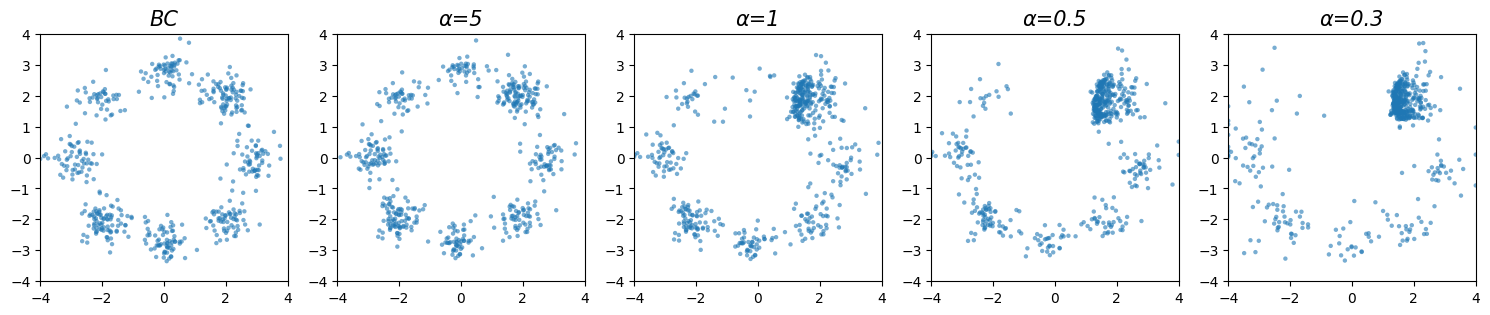

In [ ]:
fbrac_results = []

for ALPHA in ALPHAS:
    fbrac_outer_flow_params, fbrac_outer_critic_params, fbrac_outer_bc_policy_params, fbrac_outer_history = train_fbrac(
        x_1_data, rewards_data, 
        epochs=EPOCHS, 
        lr=LEARNING_RATE, 
        alpha=ALPHA,  # BC regularization weight
        hidden=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        flow_steps=FLOW_STEPS,
        plot_every=PLOT_STEP,  # Plot every 1000 epochs
        use_target_network=USE_TARGET_NETWORK,
        tau=TAU
    )
    fbrac_results.append((ALPHA, fbrac_outer_flow_params, fbrac_outer_bc_policy_params))


# Sort alphas in decreasing order for plotting
fbrac_results_sorted = sorted(fbrac_results, key=lambda x: x[0], reverse=True)
n_cols = 1 + len(fbrac_results_sorted)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3))
if n_cols == 1:
    axes = [axes]

# BC baseline: output of BC-trained flow policy (as stored, shape matches expected for flow)
ax0 = axes[0]
z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))
bc_flow_params = fbrac_results_sorted[0][2]
# Defensive: if bc_flow_params is a tuple (from possible storage / wrapping), extract first
if isinstance(bc_flow_params, tuple):
    bc_flow_params_to_use = bc_flow_params[0]
else:
    bc_flow_params_to_use = bc_flow_params
try:
    bc_actions = np.array(integrate_flow(bc_flow_params_to_use, z_eval, steps=FLOW_STEPS))
except TypeError:
    # Fall back on utility wrapper (handles possible legacy flow param signatures)
    bc_actions = np.array(integrate_flow_with_time(bc_flow_params_to_use, z_eval, steps=FLOW_STEPS))
ax0.scatter(
    bc_actions[:, 0],
    bc_actions[:, 1],
    s=10,
    alpha=0.6,
    edgecolors='none'
)
ax0.set_title("BC", fontsize=15, fontstyle='italic')
ax0.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax0.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax0.set_aspect('equal')

# Offline RL flow policies per alpha (no coloring)
for i, (alpha, flow_params, _) in enumerate(fbrac_results_sorted):
    # Handle tuple wrapping as above
    if isinstance(flow_params, tuple):
        flow_params_to_use = flow_params[0]
    else:
        flow_params_to_use = flow_params
    try:
        actions = np.array(integrate_flow(flow_params_to_use, z_eval, steps=FLOW_STEPS))
    except TypeError:
        actions = np.array(integrate_flow_with_time(flow_params_to_use, z_eval, steps=FLOW_STEPS))
    ax = axes[i + 1]
    ax.scatter(
        actions[:, 0],
        actions[:, 1],
        s=10,
        alpha=0.6,
        edgecolors='none'
    )
    ax.set_title(f'α={alpha}', fontsize=15, fontstyle='italic')
    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

BAM (JAX): 100%|██████████| 6000/6000 [02:54<00:00, 34.29it/s]


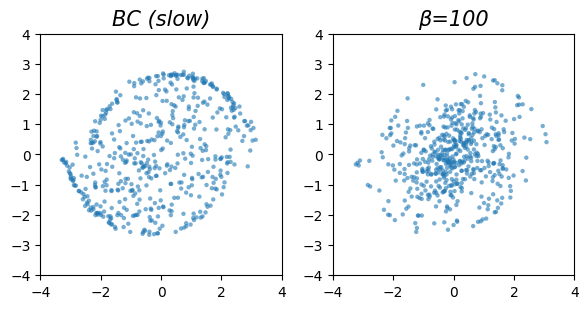

In [19]:
# ============================================================================
# RUN BAM
# ============================================================================

INV_TEMPS = [100]   # main BAM hyperparameter (like alpha list)
RHO = 0
NUM_QS = 1
TARGET_ACTOR = False
RESIDUAL = False

bam_results = []

for INV_TEMP in INV_TEMPS:
    bam_actor_slow_params, bam_actor_fast_params, bam_critic_params, bam_bc_policy_params, bam_history = train_bam(
        x_1_data, rewards_data,
        epochs=6000,
        lr=LEARNING_RATE,
        inv_temp=INV_TEMP,
        flow_steps=FLOW_STEPS,
        plot_every=PLOT_STEP,
        rho=RHO,
        num_qs=NUM_QS,
        use_target_network=USE_TARGET_NETWORK,
        tau=TAU,
        target_actor=TARGET_ACTOR,
        residual=RESIDUAL,
        batch_size=BATCH_SIZE,
        num_evals=NUM_EVALS,
        bc_epochs=5000,
        save_dir=SAVE_DIR,
    )
    bam_results.append((INV_TEMP, bam_actor_slow_params, bam_actor_fast_params, bam_bc_policy_params))

# Sort inv_temp decreasing for plotting
bam_results_sorted = sorted(bam_results, key=lambda x: x[0], reverse=True)
n_cols = 1 + len(bam_results_sorted)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3))
if n_cols == 1:
    axes = [axes]

z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))

# BC baseline: actor_slow at end of BC warmup
ax0 = axes[0]
bc_slow_params = bam_results_sorted[0][3]
bc_actions = np.array(integrate_flow_from(bc_slow_params, z_eval, jnp.zeros((z_eval.shape[0], 1)), steps=FLOW_STEPS))
ax0.scatter(bc_actions[:, 0], bc_actions[:, 1], s=10, alpha=0.6, edgecolors='none')
ax0.set_title("BC (slow)", fontsize=15, fontstyle='italic')
ax0.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax0.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax0.set_aspect('equal')

# Offline RL policies per inv_temp: use fast (or slow+fast if RESIDUAL=True)
for i, (inv_temp, slow_params, fast_params, _) in enumerate(bam_results_sorted):
    actions = integrate_flow_from(fast_params, z_eval, jnp.zeros((z_eval.shape[0], 1)), steps=FLOW_STEPS)
    actions = np.array(actions)
    ax = axes[i + 1]
    ax.scatter(actions[:, 0], actions[:, 1], s=10, alpha=0.6, edgecolors='none')
    ax.set_title(f'β={inv_temp}', fontsize=15, fontstyle='italic')
    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

fbrac_inner (JAX): 100%|██████████| 2100/2100 [00:45<00:00, 46.12it/s]


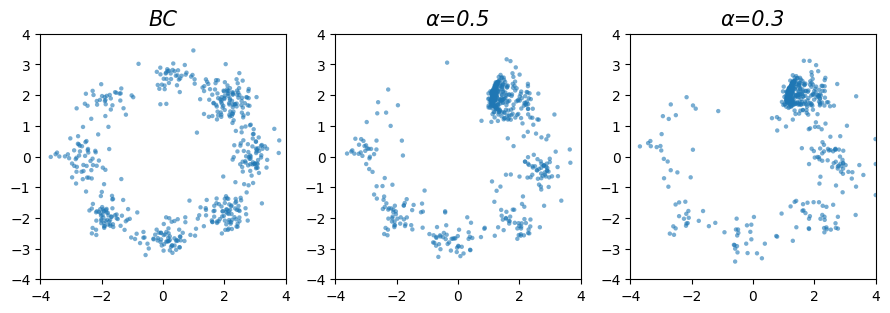

In [21]:
# Experiment parameters
FLOW_STEPS = 8
NUM_LAYERS = 4
HIDDEN_DIM = 512
BC_EPOCHS = 2000
OFFLINE_EPOCHS = 100
LEARNING_RATE = 3e-4
BATCH_SIZE = 4096
NUM_PLOTS = 2
NUM_EVALS = 512

epochs = BC_EPOCHS + OFFLINE_EPOCHS

# Alpha values (regularization/guidance coefficients)
ALPHAS = [0.5, 0.3]

# Target network settings
USE_TARGET_NETWORK = False
TAU = 0.005  # EMA rate for target network updates


# Calculate derived parameters
EPOCHS = BC_EPOCHS + OFFLINE_EPOCHS
PLOT_STEP = EPOCHS // NUM_PLOTS if NUM_PLOTS > 0 else None


fbrac_inner_results = []

for ALPHA in ALPHAS:
    fbrac_inner_flow_params, fbrac_inner_critic_params, fbrac_inner_bc_policy_params, fbrac_history = train_fbrac_inner(
        x_1_data, rewards_data, 
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        alpha=ALPHA,  # Weight for V-maximization
        flow_steps=FLOW_STEPS,
        plot_every=PLOT_STEP,  # Plot every 1000 epochs
        use_time_embed=False,
        time_embed_dim=16,
        hidden=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        max_time_penalty=0.0,
        time_weight=False,
        use_residual=False,
        fbrac_inner_policy_loss_type="vgg_flow_matching",
        expectile=0.5,
        use_target_network=USE_TARGET_NETWORK,
        tau=TAU,
        integration_method="rk4"
    )
    fbrac_inner_results.append((ALPHA, fbrac_inner_flow_params, fbrac_inner_bc_policy_params))

# Sort alphas in decreasing order for plotting
fbrac_inner_results_sorted = sorted(fbrac_inner_results, key=lambda x: x[0], reverse=True)
n_cols = 1 + len(fbrac_inner_results_sorted)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3))
if n_cols == 1:
    axes = [axes]

# BC baseline: output of BC-trained flow policy from FBRAC-Inner
ax0 = axes[0]
z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))
bc_flow_params = fbrac_inner_results_sorted[0][2]
if isinstance(bc_flow_params, tuple):
    bc_flow_params_to_use = bc_flow_params[0]
else:
    bc_flow_params_to_use = bc_flow_params
try:
    bc_actions = np.array(integrate_flow(bc_flow_params_to_use, z_eval, steps=FLOW_STEPS))
except TypeError:
    bc_actions = np.array(integrate_flow_with_time(bc_flow_params_to_use, z_eval, steps=FLOW_STEPS))
ax0.scatter(
    bc_actions[:, 0],
    bc_actions[:, 1],
    s=10,
    alpha=0.6,
    edgecolors='none'
)
ax0.set_title("BC", fontsize=15, fontstyle='italic')
ax0.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax0.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax0.set_aspect('equal')

# Offline RL flow policies per alpha (no coloring)
for i, (alpha, flow_params, _) in enumerate(fbrac_inner_results_sorted):
    if isinstance(flow_params, tuple):
        flow_params_to_use = flow_params[0]
    else:
        flow_params_to_use = flow_params
    try:
        actions = np.array(integrate_flow(flow_params_to_use, z_eval, steps=FLOW_STEPS))
    except TypeError:
        actions = np.array(integrate_flow_with_time(flow_params_to_use, z_eval, steps=FLOW_STEPS))
    ax = axes[i + 1]
    ax.scatter(
        actions[:, 0],
        actions[:, 1],
        s=10,
        alpha=0.6,
        edgecolors='none'
    )
    ax.set_title(f'α={alpha}', fontsize=15, fontstyle='italic')
    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect('equal')

plt.tight_layout()
# save_dir = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac_inner'
# os.makedirs(save_dir, exist_ok=True)
plt.show()
# plt.savefig(
#     f'{save_dir}/final_results_flow{FLOW_STEPS}_layers{num_layers}_hidden{hidden_dim}_data{N_DATA}_epochs{epochs}.png',
#     dpi=100,
#     bbox_inches='tight'
# )
# plt.close()

fbrac_inner (JAX): 100%|██████████| 2100/2100 [00:30<00:00, 68.59it/s] 


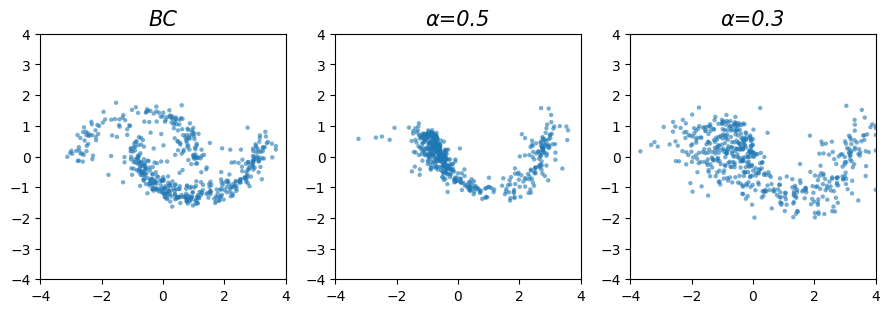

In [ ]:
# Experiment parameters
FLOW_STEPS = 25
NUM_LAYERS = 4
HIDDEN_DIM = 512
BC_EPOCHS = 2000
OFFLINE_EPOCHS = 100
LEARNING_RATE = 3e-4
BATCH_SIZE = 4096
NUM_PLOTS = 10
NUM_EVALS = 512

epochs = BC_EPOCHS + OFFLINE_EPOCHS

# Alpha values (regularization/guidance coefficients)
ALPHAS = [0.5, 0.3]

# Target network settings
USE_TARGET_NETWORK = False
TAU = 0.005  # EMA rate for target network updates


# Calculate derived parameters
EPOCHS = BC_EPOCHS + OFFLINE_EPOCHS
PLOT_STEP = EPOCHS // NUM_PLOTS if NUM_PLOTS > 0 else None


fbrac_inner_results = []

for ALPHA in ALPHAS:
    fbrac_inner_flow_params, fbrac_inner_critic_params, fbrac_inner_bc_policy_params, fbrac_history = train_fbrac_inner(
        x_1_data, rewards_data, 
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        alpha=ALPHA,  # Weight for V-maximization
        flow_steps=FLOW_STEPS,
        plot_every=PLOT_STEP,  # Plot every 1000 epochs
        use_time_embed=False,
        time_embed_dim=16,
        hidden=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        max_time_penalty=0.0,
        time_weight=False,
        use_residual=False,
        fbrac_inner_policy_loss_type="vgg_flow_matching",
        expectile=0.5,
        use_target_network=USE_TARGET_NETWORK,
        tau=TAU,
        integration_method="euler"
    )
    fbrac_inner_results.append((ALPHA, fbrac_inner_flow_params, fbrac_inner_bc_policy_params))

# Sort alphas in decreasing order for plotting
fbrac_inner_results_sorted = sorted(fbrac_inner_results, key=lambda x: x[0], reverse=True)
n_cols = 1 + len(fbrac_inner_results_sorted)
fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3))
if n_cols == 1:
    axes = [axes]

# BC baseline: output of BC-trained flow policy from FBRAC-Inner
ax0 = axes[0]
z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))
bc_flow_params = fbrac_inner_results_sorted[0][2]
if isinstance(bc_flow_params, tuple):
    bc_flow_params_to_use = bc_flow_params[0]
else:
    bc_flow_params_to_use = bc_flow_params
try:
    bc_actions = np.array(integrate_flow(bc_flow_params_to_use, z_eval, steps=FLOW_STEPS))
except TypeError:
    bc_actions = np.array(integrate_flow_with_time(bc_flow_params_to_use, z_eval, steps=FLOW_STEPS))
ax0.scatter(
    bc_actions[:, 0],
    bc_actions[:, 1],
    s=10,
    alpha=0.6,
    edgecolors='none'
)
ax0.set_title("BC", fontsize=15, fontstyle='italic')
ax0.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax0.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
ax0.set_aspect('equal')

# Offline RL flow policies per alpha (no coloring)
for i, (alpha, flow_params, _) in enumerate(fbrac_inner_results_sorted):
    if isinstance(flow_params, tuple):
        flow_params_to_use = flow_params[0]
    else:
        flow_params_to_use = flow_params
    try:
        actions = np.array(integrate_flow(flow_params_to_use, z_eval, steps=FLOW_STEPS))
    except TypeError:
        actions = np.array(integrate_flow_with_time(flow_params_to_use, z_eval, steps=FLOW_STEPS))
    ax = axes[i + 1]
    ax.scatter(
        actions[:, 0],
        actions[:, 1],
        s=10,
        alpha=0.6,
        edgecolors='none'
    )
    ax.set_title(f'α={alpha}', fontsize=15, fontstyle='italic')
    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX); ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect('equal')

plt.tight_layout()
# save_dir = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac_inner'
# os.makedirs(save_dir, exist_ok=True)
plt.show()
# plt.savefig(
#     f'{save_dir}/final_results_flow{FLOW_STEPS}_layers{num_layers}_hidden{hidden_dim}_data{N_DATA}_epochs{epochs}.png',
#     dpi=100,
#     bbox_inches='tight'
# )
# plt.close()

## Final Plot

### Full Toy 2-D Experiment Results

In [8]:
import pickle
SAVE_DIR="toy_experiment/activation_test"
DATASET_TYPE="swissroll"
FLOW_STEPS=25
NUM_LAYERS=4
HIDDEN_DIM=512
N_DATA=10000
EPOCHS=2100


# Load all saved weights for all alphas
ALPHAS = [5.0, 1.0, 0.5, 0.3]
fbrac_inner_results = []

# Load all saved weights for all alphas - FBRAC-Inner (TVL)

for ALPHA in ALPHAS:
    weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac_inner/weights_alpha{ALPHA}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'
    
    try:
        with open(weights_path, 'rb') as f:
            loaded_weights = pickle.load(f)
        
        flow_params = loaded_weights['flow_params']
        bc_policy_params = loaded_weights['bc_policy_params']
        fbrac_inner_results.append((ALPHA, flow_params, bc_policy_params))
        print(f"Loaded FBRAC-Inner weights for alpha={ALPHA}")
    except FileNotFoundError:
        print(f"FBRAC-Inner weights not found for alpha={ALPHA}, skipping...")

print(f"Loaded {len(fbrac_inner_results)} FBRAC-Inner model(s)")

# Load all saved weights for all alphas - FQL
fql_results = []

for ALPHA in ALPHAS:
    weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fql/weights_alpha{ALPHA}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'
    
    try:
        with open(weights_path, 'rb') as f:
            loaded_weights = pickle.load(f)
        
        policy_params = loaded_weights['policy_params']
        bc_policy_params = loaded_weights['bc_policy_params']
        fql_results.append((ALPHA, policy_params, bc_policy_params))
        print(f"Loaded FQL weights for alpha={ALPHA}")
    except FileNotFoundError:
        print(f"FQL weights not found for alpha={ALPHA}, skipping...")

print(f"Loaded {len(fql_results)} FQL model(s)")

# Load all saved weights for all alphas - FBRAC
fbrac_results = []

for ALPHA in ALPHAS:
    weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac/weights_alpha{ALPHA}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'
    
    try:
        with open(weights_path, 'rb') as f:
            loaded_weights = pickle.load(f)
        
        flow_params = loaded_weights['flow_params']
        bc_policy_params = loaded_weights['bc_policy_params']
        fbrac_results.append((ALPHA, flow_params, bc_policy_params))
        print(f"Loaded FBRAC weights for alpha={ALPHA}")
    except FileNotFoundError:
        print(f"FBRAC weights not found for alpha={ALPHA}, skipping...")

print(f"Loaded {len(fbrac_results)} FBRAC model(s)")

# Sort results for plotting
fbrac_inner_results_sorted = sorted(fbrac_inner_results, key=lambda x: x[0], reverse=True)
fql_results_sorted = sorted(fql_results, key=lambda x: x[0], reverse=True)
fbrac_results_sorted = sorted(fbrac_results, key=lambda x: x[0], reverse=True)

print(f"\nSummary:")
print(f"  FBRAC-Inner: {len(fbrac_inner_results_sorted)} models")
print(f"  FQL: {len(fql_results_sorted)} models")
print(f"  FBRAC: {len(fbrac_results_sorted)} models")

Loaded FBRAC-Inner weights for alpha=5.0
Loaded FBRAC-Inner weights for alpha=1.0
Loaded FBRAC-Inner weights for alpha=0.5
Loaded FBRAC-Inner weights for alpha=0.3
Loaded 4 FBRAC-Inner model(s)
Loaded FQL weights for alpha=5.0
Loaded FQL weights for alpha=1.0
Loaded FQL weights for alpha=0.5
Loaded FQL weights for alpha=0.3
Loaded 4 FQL model(s)
Loaded FBRAC weights for alpha=5.0
Loaded FBRAC weights for alpha=1.0
Loaded FBRAC weights for alpha=0.5
Loaded FBRAC weights for alpha=0.3
Loaded 4 FBRAC model(s)

Summary:
  FBRAC-Inner: 4 models
  FQL: 4 models
  FBRAC: 4 models


KeyboardInterrupt: 

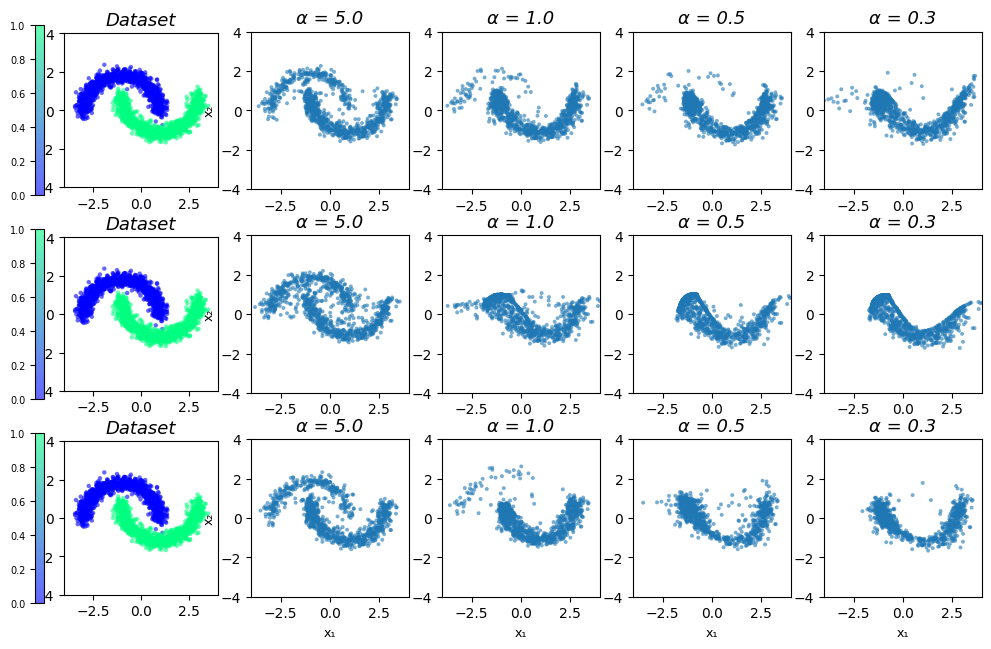

In [50]:
# ============================================================================
# Comparison Plot: All Methods Across Alphas
# ============================================================================

NUM_EVALS=1024

# Check which results are available
has_fql = 'fql_results_sorted' in globals() and len(fql_results_sorted) > 0
has_fbrac = 'fbrac_results_sorted' in globals() and len(fbrac_results_sorted) > 0
has_tvl = 'fbrac_inner_results_sorted' in globals() and len(fbrac_inner_results_sorted) > 0

if not (has_fql or has_fbrac or has_tvl):
    print("No results available. Please run the training cells first.")
else:
    # Get the maximum number of alphas across all methods
    max_alphas = 0
    if has_fql:
        max_alphas = max(max_alphas, len(fql_results_sorted))
    if has_fbrac:
        max_alphas = max(max_alphas, len(fbrac_results_sorted))
    if has_tvl:
        max_alphas = max(max_alphas, len(fbrac_inner_results_sorted))
    
    # Number of rows: 3 methods (FBRAC, FQL, TVL)
    n_rows = 3
    # Number of columns: 1 (Dataset) + number of alphas
    n_cols = 1 + max_alphas
    
    width_ratios = [1.3] + [1] * max_alphas
    
    fig, axes = plt.subplots(
        n_rows, n_cols, 
        figsize=(2.5 * n_cols, 2.5 * n_rows),
        gridspec_kw={'width_ratios': width_ratios}
    )
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    if n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))
    
    # Sample dataset for visualization
    np.random.seed(42)
    dataset_samples, dataset_rewards = sample_from_dataset(2000)
    dataset_rewards = dataset_rewards.flatten()
    
    # Column 0: Dataset plot with reward coloring for each method row
    col = 0
    
    # FBRAC row - Dataset
    sc1 = axes[0, col].scatter(dataset_samples[:, 0], dataset_samples[:, 1], 
                               c=dataset_rewards, cmap='winter', s=10, alpha=0.6, edgecolors='none')
    axes[0, col].set_title("Dataset", fontsize=13, fontstyle='italic')
    axes[0, col].set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    axes[0, col].set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    axes[0, col].set_aspect('equal')
    cbar1 = plt.colorbar(sc1, ax=axes[0, col], location='left', pad=0.1)
    cbar1.ax.tick_params(labelsize=7)
    
    # FQL row - Dataset
    sc2 = axes[1, col].scatter(dataset_samples[:, 0], dataset_samples[:, 1], 
                               c=dataset_rewards, cmap='winter', s=10, alpha=0.6, edgecolors='none')
    axes[1, col].set_title("Dataset", fontsize=13, fontstyle='italic')
    axes[1, col].set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    axes[1, col].set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    axes[1, col].set_aspect('equal')
    cbar2 = plt.colorbar(sc2, ax=axes[1, col], location='left', pad=0.1)
    cbar2.ax.tick_params(labelsize=7)
    
    # TVL row - Dataset
    sc3 = axes[2, col].scatter(dataset_samples[:, 0], dataset_samples[:, 1], 
                               c=dataset_rewards, cmap='winter', s=10, alpha=0.6, edgecolors='none')
    axes[2, col].set_title("Dataset", fontsize=13, fontstyle='italic')
    axes[2, col].set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    axes[2, col].set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    axes[2, col].set_aspect('equal')
    cbar3 = plt.colorbar(sc3, ax=axes[2, col], location='left', pad=0.1)
    cbar3.ax.tick_params(labelsize=7)
    
    # Subsequent columns: Different alphas
    for alpha_idx in range(max_alphas):
        col = 1 + alpha_idx
        
        # FBRAC
        if has_fbrac and alpha_idx < len(fbrac_results_sorted):
            alpha, flow_params, _ = fbrac_results_sorted[alpha_idx]
            if isinstance(flow_params, tuple):
                flow_params = flow_params[0]
            try:
                actions = np.array(integrate_flow(flow_params, z_eval, steps=FLOW_STEPS))
            except:
                actions = np.array(integrate_flow_with_time(flow_params, z_eval, steps=FLOW_STEPS))
            axes[0, col].scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
            axes[0, col].set_title(f'α = {alpha}', fontsize=13, fontstyle='italic')
        else:
            axes[0, col].axis('off')
        
        # FQL
        if has_fql and alpha_idx < len(fql_results_sorted):
            alpha, policy_params, _ = fql_results_sorted[alpha_idx]
            actions = np.array(onestep_forward(policy_params, z_eval))
            axes[1, col].scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
            axes[1, col].set_title(f'α = {alpha}', fontsize=13, fontstyle='italic')
        else:
            axes[1, col].axis('off')
        
        # TVL (FBRAC-Inner)
        if has_tvl and alpha_idx < len(fbrac_inner_results_sorted):
            alpha, flow_params, _ = fbrac_inner_results_sorted[alpha_idx]
            if isinstance(flow_params, tuple):
                flow_params = flow_params[0]
            try:
                actions = np.array(integrate_flow(flow_params, z_eval, steps=FLOW_STEPS))
            except:
                actions = np.array(integrate_flow_with_time(flow_params, z_eval, steps=FLOW_STEPS))
            axes[2, col].scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
            axes[2, col].set_title(f'α = {alpha}', fontsize=13, fontstyle='italic')
        else:
            axes[2, col].axis('off')
    
    # Set axis properties for all subplots
    for row in range(n_rows):
        for col in range(n_cols):
            if col > 0:  # Skip dataset column (already set)
                axes[row, col].set_xlim(DOMAIN_MIN, DOMAIN_MAX)
                axes[row, col].set_ylim(DOMAIN_MIN, DOMAIN_MAX)
                axes[row, col].set_aspect('equal')
                if row == n_rows - 1:  # Bottom row
                    axes[row, col].set_xlabel('x₁', fontsize=9)
                if col == 1:  # First alpha column
                    axes[row, col].set_ylabel('x₂', fontsize=9)
    
    plt.tight_layout()
    
    # Optionally save the figure
    save_dir = f'{SAVE_DIR}/{DATASET_TYPE}'
    os.makedirs(save_dir, exist_ok=True)
    # plt.savefig(f'{save_dir}/comparison_all_methods_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.png',
    #             dpi=100, bbox_inches='tight')
    plt.show()

In [53]:
# ============================================================================
# Comparison Plot: All Methods Across Alphas (Separate Plots)
# ============================================================================

# NOTE: For colorbar placement, we use make_axes_locatable from mpl_toolkits.
from mpl_toolkits.axes_grid1 import make_axes_locatable

NUM_EVALS = 1024

# Check which results are available
has_fql = 'fql_results_sorted' in globals() and len(fql_results_sorted) > 0
has_fbrac = 'fbrac_results_sorted' in globals() and len(fbrac_results_sorted) > 0
has_tvl = 'fbrac_inner_results_sorted' in globals() and len(fbrac_inner_results_sorted) > 0

if not (has_fql or has_fbrac or has_tvl):
    print("No results available. Please run the training cells first.")
else:
    z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))

    # Sample dataset for visualization
    np.random.seed(42)
    dataset_samples, dataset_rewards = sample_from_dataset(2000)
    dataset_rewards = dataset_rewards.flatten()

    save_dir = f'{SAVE_DIR}/{DATASET_TYPE}'
    os.makedirs(save_dir, exist_ok=True)

    # --------- SAVE DATASET PLOT INDIVIDUALLY, WIDTH = num_alphas ---------
    # Compute max number of alphas across all methods (for width)
    max_alphas = 0
    if has_fbrac:
        max_alphas = max(max_alphas, len(fbrac_results_sorted))
    if has_fql:
        max_alphas = max(max_alphas, len(fql_results_sorted))
    if has_tvl:
        max_alphas = max(max_alphas, len(fbrac_inner_results_sorted))
    n_cols = max_alphas if max_alphas > 0 else 1  # Avoid zero cols

    from matplotlib.gridspec import GridSpec

    # ------------------------------------------------------------
    # Configuration
    # ------------------------------------------------------------

    # max_alphas should already be computed
    assert max_alphas > 0, "max_alphas must be > 0"

    # ------------------------------------------------------------
    # Figure + GridSpec
    # Overall width stays tied to number of alphas
    # ------------------------------------------------------------
    fig = plt.figure(figsize=(2.5 * max_alphas, 2.5))

    # One row, (dataset + alpha columns)
    width_ratios = [1.15] + [1.0] * 3
    gs = GridSpec(
        1,
        max_alphas,
        width_ratios=width_ratios,
        figure=fig
    )

    # ------------------------------------------------------------
    # Dataset axis (ONLY this one is used)
    # ------------------------------------------------------------
    ax = fig.add_subplot(gs[0, 0])

    sc = ax.scatter(
        dataset_samples[:, 0],
        dataset_samples[:, 1],
        c=dataset_rewards,
        cmap="winter",
        s=10,
        alpha=0.6,
        edgecolors="none"
    )

    ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax.set_aspect("equal")

    # Use make_axes_locatable to place the colorbar immediately to the right of the axis
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(sc, cax=cax)
    cbar.set_label('Reward', fontsize=12, rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=10)

    # ------------------------------------------------------------
    # Hide all unused alpha columns completely
    # ------------------------------------------------------------
    for c in range(1, max_alphas):
        ax_blank = fig.add_subplot(gs[0, c])
        ax_blank.axis("off")
    plt.tight_layout()
    plt.savefig(f'{save_dir}/{DATASET_TYPE}_dataset_full.png', dpi=100)
    plt.close()
    print(f"Saved dataset plot: {DATASET_TYPE}_dataset_full.png")
    # --------------------------------------------------------------------------

    # Define method configurations: (method_name, results_list, plot_filename)
    methods = []
    if has_fbrac:
        methods.append(('FBRAC', fbrac_results_sorted, f'{DATASET_TYPE}_fbrac_full.png'))
    if has_fql:
        methods.append(('FQL', fql_results_sorted, f'{DATASET_TYPE}_fql_full.png'))
    if has_tvl:
        methods.append(('TVL', fbrac_inner_results_sorted, f'{DATASET_TYPE}_tvl_full.png'))

    # Create a separate plot for each method
    for method_name, results_sorted, filename in methods:
        n_alphas = len(results_sorted)
        if n_alphas == 0:
            continue

        n_cols = n_alphas
        fig, axes = plt.subplots(
            1, n_cols,
            figsize=(2.5 * n_cols, 2.5),
        )
        if n_cols == 1:
            axes = np.array([axes])
        axes = axes.flatten()

        for alpha_idx in range(n_alphas):
            alpha, params, _ = results_sorted[alpha_idx]

            if method_name == 'FQL':
                # FQL uses policy_params directly
                actions = np.array(onestep_forward(params, z_eval))
            else:
                # FBRAC and TVL use flow_params
                flow_params = params
                if isinstance(flow_params, tuple):
                    flow_params = flow_params[0]
                try:
                    actions = np.array(integrate_flow(flow_params, z_eval, steps=FLOW_STEPS))
                except:
                    actions = np.array(integrate_flow_with_time(flow_params, z_eval, steps=FLOW_STEPS))

            axes[alpha_idx].scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
            axes[alpha_idx].set_title(f'α = {alpha}', fontsize=13, fontstyle='italic')
            axes[alpha_idx].set_xlim(DOMAIN_MIN, DOMAIN_MAX)
            axes[alpha_idx].set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            axes[alpha_idx].set_aspect('equal')

        plt.tight_layout()

        # Save the figure
        plt.savefig(f'{save_dir}/{filename}',
                    dpi=100, bbox_inches='tight')
        plt.close()
        print(f"Saved {method_name} plot: {filename}")

Saved dataset plot: eight_gaussians_dataset_full.png
Saved FBRAC plot: eight_gaussians_fbrac_full.png
Saved FQL plot: eight_gaussians_fql_full.png
Saved TVL plot: eight_gaussians_tvl_full.png


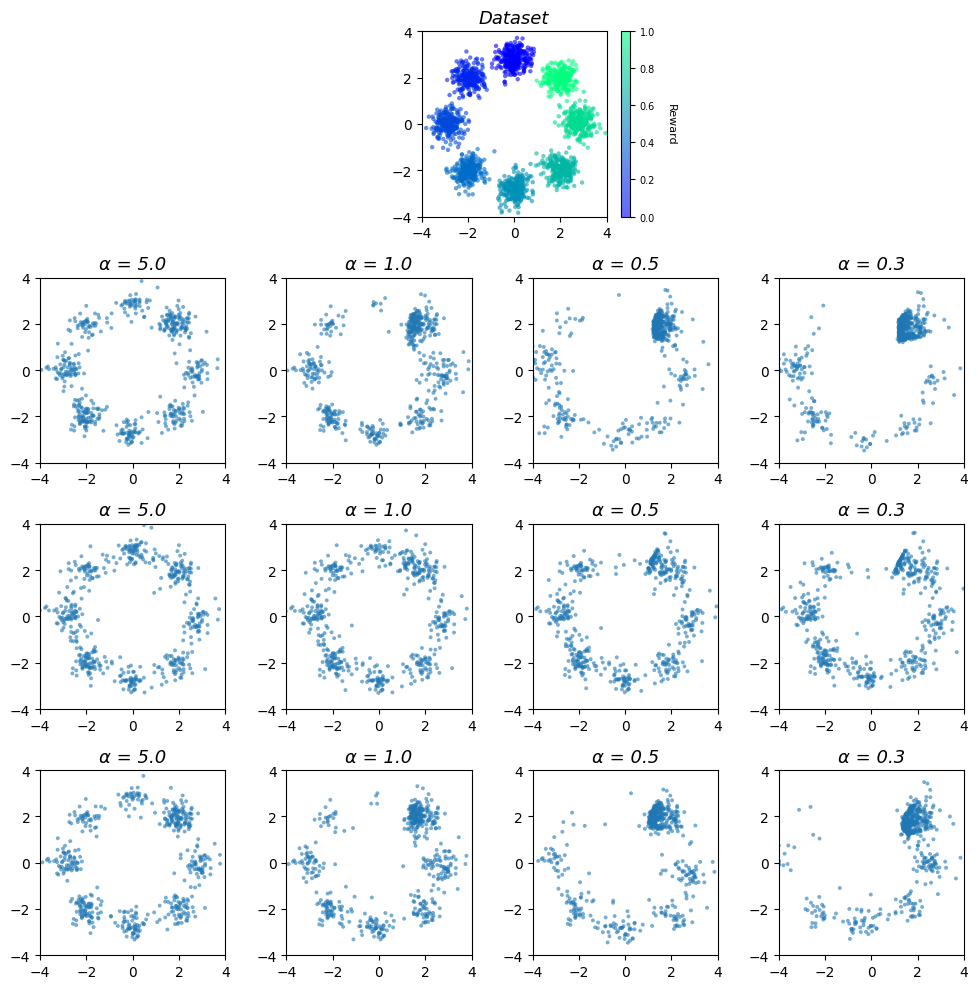

In [106]:
# ============================================================================
# Comparison Plot: All Methods Across Alphas
# ============================================================================

NUM_EVALS=512

# Check which results are available
has_fql = 'fql_results_sorted' in globals() and len(fql_results_sorted) > 0
has_fbrac = 'fbrac_results_sorted' in globals() and len(fbrac_results_sorted) > 0
has_tvl = 'fbrac_inner_results_sorted' in globals() and len(fbrac_inner_results_sorted) > 0

if not (has_fql or has_fbrac or has_tvl):
    print("No results available. Please run the training cells first.")
else:
    # Get the maximum number of alphas across all methods
    max_alphas = 0
    if has_fql:
        max_alphas = max(max_alphas, len(fql_results_sorted))
    if has_fbrac:
        max_alphas = max(max_alphas, len(fbrac_results_sorted))
    if has_tvl:
        max_alphas = max(max_alphas, len(fbrac_inner_results_sorted))
    
    # Number of rows: 1 (Dataset) + 3 methods (FBRAC, FQL, TVL)
    n_rows = 4
    # Number of columns: number of alphas
    n_cols = max_alphas
    
    # Create figure with GridSpec - reduced spacing
    fig = plt.figure(figsize=(2.5 * n_cols, 2.5 * n_rows))
    gs = fig.add_gridspec(n_rows, n_cols)
    
    z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))
    
    # Sample dataset for visualization
    np.random.seed(42)
    dataset_samples, dataset_rewards = sample_from_dataset(2000)
    dataset_rewards = dataset_rewards.flatten()
    
    # Store axes for method plots to set labels later
    method_axes = [[None] * max_alphas for _ in range(3)]
    
    # Row 0: Dataset plot centered in middle columns
    # Center the dataset plot - span middle columns
    if max_alphas >= 3:
        # Span middle 3 columns if we have enough columns
        col_dataset_start = max(0, (max_alphas - 3) // 2)
        col_dataset_end = col_dataset_start + 2
    else:
        # If fewer columns, span all
        col_dataset_start = 0
        col_dataset_end = max_alphas - 1
    
    # Create dataset plot spanning middle columns
    ax_dataset = fig.add_subplot(gs[0, col_dataset_start:col_dataset_end+1])
    sc = ax_dataset.scatter(dataset_samples[:, 0], dataset_samples[:, 1], 
                           c=dataset_rewards, cmap='winter', s=10, alpha=0.6, edgecolors='none')
    ax_dataset.set_title("Dataset", fontsize=13, fontstyle='italic')
    ax_dataset.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    ax_dataset.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax_dataset.set_aspect('equal')
    
    # Colorbar directly to the right of the dataset plot
    cbar = plt.colorbar(sc, ax=ax_dataset, location='right', pad=0.02)
    cbar.set_label('Reward', fontsize=8, rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=7)
    
    # Rows 1-3: Methods (FBRAC, FQL, TVL)
    for alpha_idx in range(max_alphas):
        col = alpha_idx
        
        # FBRAC (row 1)
        if has_fbrac and alpha_idx < len(fbrac_results_sorted):
            alpha, flow_params, _ = fbrac_results_sorted[alpha_idx]
            if isinstance(flow_params, tuple):
                flow_params = flow_params[0]
            try:
                actions = np.array(integrate_flow(flow_params, z_eval, steps=FLOW_STEPS))
            except:
                actions = np.array(integrate_flow_with_time(flow_params, z_eval, steps=FLOW_STEPS))
            ax = fig.add_subplot(gs[1, col])
            method_axes[0][alpha_idx] = ax
            ax.scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
            ax.set_title(f'α = {alpha}', fontsize=13, fontstyle='italic')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')
        else:
            ax = fig.add_subplot(gs[1, col])
            method_axes[0][alpha_idx] = ax
            ax.axis('off')
        
        # FQL (row 2)
        if has_fql and alpha_idx < len(fql_results_sorted):
            alpha, policy_params, _ = fql_results_sorted[alpha_idx]
            actions = np.array(onestep_forward(policy_params, z_eval))
            ax = fig.add_subplot(gs[2, col])
            method_axes[1][alpha_idx] = ax
            ax.scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
            ax.set_title(f'α = {alpha}', fontsize=13, fontstyle='italic')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')
        else:
            ax = fig.add_subplot(gs[2, col])
            method_axes[1][alpha_idx] = ax
            ax.axis('off')
        
        # TVL (FBRAC-Inner) (row 3)
        if has_tvl and alpha_idx < len(fbrac_inner_results_sorted):
            alpha, flow_params, _ = fbrac_inner_results_sorted[alpha_idx]
            if isinstance(flow_params, tuple):
                flow_params = flow_params[0]
            try:
                actions = np.array(integrate_flow(flow_params, z_eval, steps=FLOW_STEPS))
            except:
                actions = np.array(integrate_flow_with_time(flow_params, z_eval, steps=FLOW_STEPS))
            ax = fig.add_subplot(gs[3, col])
            method_axes[2][alpha_idx] = ax
            ax.scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
            ax.set_title(f'α = {alpha}', fontsize=13, fontstyle='italic')
            ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
            ax.set_aspect('equal')
        else:
            ax = fig.add_subplot(gs[3, col])
            method_axes[2][alpha_idx] = ax
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Optionally save the figure
    # save_dir = f'{SAVE_DIR}/{DATASET_TYPE}'
    # os.makedirs(save_dir, exist_ok=True)
    # plt.savefig(f'{save_dir}/comparison_all_methods_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.png',
    #             dpi=100, bbox_inches='tight')
    # plt.close()

### Value Landscape Over Flow timesteps

Loaded FBRAC-Inner weights for alpha=0.5


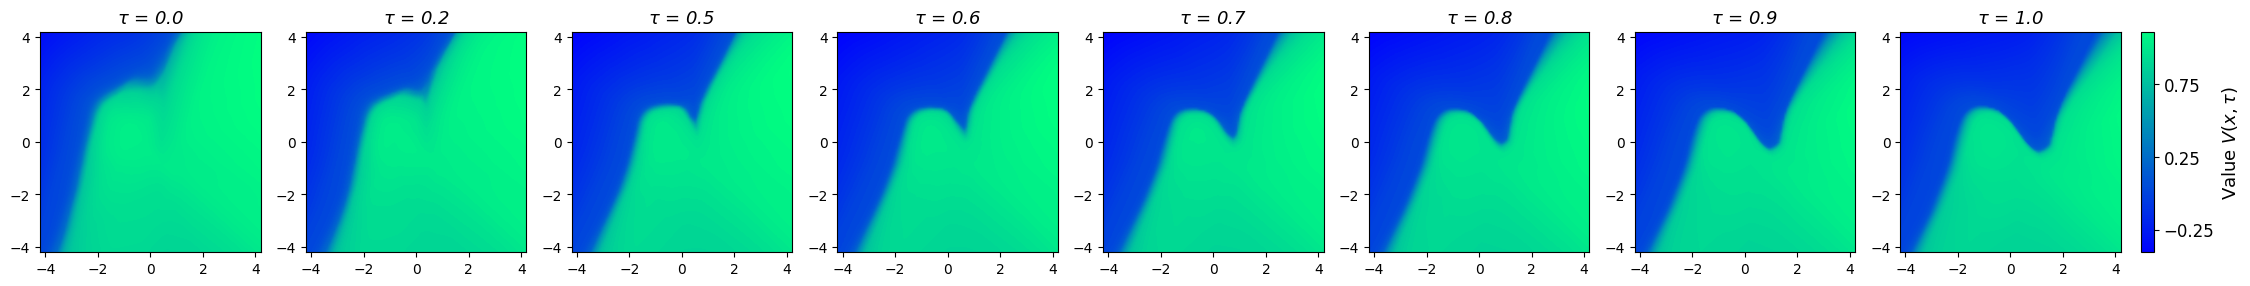

In [ ]:
# ============================================================================
# PLOT FBRAC_INNER Q LANDSCAPE AND POLICY VELOCITIES OVER SAMPLING TIMESTEPS
# => How to smooth out the landscape: apply gaussian filter to the value surface before plotting
# ============================================================================

import pickle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import gaussian_filter  # <-- Add smoothing capability
DATASET_TYPE="two_spirals"
SAVE_DIR="toy_experiment/activation_test"
FLOW_STEPS=25
NUM_LAYERS=4
HIDDEN_DIM=512
N_DATA=10000
EPOCHS=5100

# Specify which alpha to visualize
ALPHA_TO_PLOT = 0.5  # Change this to the desired alpha value

# Load weights for the specific alpha
weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac_inner/weights_alpha{ALPHA_TO_PLOT}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'

try:
    with open(weights_path, 'rb') as f:
        loaded_weights = pickle.load(f)
    
    fbrac_inner_flow_params = loaded_weights['flow_params']
    fbrac_inner_inner_critic_params = loaded_weights['inner_critic_params']

    print(f"Loaded FBRAC-Inner weights for alpha={ALPHA_TO_PLOT}")
except FileNotFoundError:
    print(f"Weights not found for alpha={ALPHA_TO_PLOT}")
    raise

# Settings
resolution = 100
plot_range = 4.2
# timesteps = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.2, 0.0]
timesteps = [0.0, 0.2, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
SMOOTH_SIGMA = 0.0  # <-- Set smoothing kernel size (can increase for more smoothness, or set to 0 to disable)

# Create grid of positions (x)
xs = np.linspace(-plot_range, plot_range, resolution)
ys = np.linspace(-plot_range, plot_range, resolution)
X, Y = np.meshgrid(xs, ys)
positions = np.stack([X.flatten(), Y.flatten()], axis=1)
positions_tensor = jnp.asarray(positions)

# Evaluate fbrac_inner critic and inner policy velocities at each timestep
fbrac_inner_V = {}
fbrac_inner_vels = {}

# Define local forward functions (matching the training code)
def _flow_forward(params, x, t):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(params, xt)

def _inner_critic_forward(params, x, t, use_residual=False):
    # Use scalar time (not time embedding) to match training
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(params, xt, use_residual=use_residual).squeeze(-1)

for t_val in timesteps:
    t_tensor = jnp.full((positions_tensor.shape[0], 1), t_val)
    
    # Value - use inner critic
    v = _inner_critic_forward(fbrac_inner_inner_critic_params, positions_tensor, t_tensor)
    V_np = np.array(v).reshape(X.shape)
    # ---- Apply smoothing -----
    if SMOOTH_SIGMA > 0.0:
        V_np = gaussian_filter(V_np, sigma=SMOOTH_SIGMA, mode='nearest')
    fbrac_inner_V[t_val] = V_np
    
    # Policy velocity: model predicts v, so velocity = v / FLOW_STEPS
    velocity = _flow_forward(fbrac_inner_flow_params, positions_tensor, t_tensor)
    velocity = np.array(velocity) / FLOW_STEPS   # scale for delta x per step
    fbrac_inner_vels[t_val] = velocity.reshape((X.shape[0], X.shape[1], 2))

# Instead of fixed ticks, set colorbar ticks to match data min/max and be more readable.
all_V = np.array([fbrac_inner_V[t] for t in timesteps])
vmin = np.min(all_V)
vmax = np.max(all_V)

# Let matplotlib choose colorbar ticks automatically, but round to neat bounds
def _nice_ticks(vmin, vmax, n=6):
    if np.allclose(vmin, vmax):
        return [float(vmin)]
    spacing = (vmax - vmin) / (n-1)
    ticks = [vmin + i*spacing for i in range(n)]
    return [np.round(tick, 2) for tick in ticks]
cbar_ticks = _nice_ticks(vmin, vmax)

import matplotlib.gridspec as gridspec
n_cols = len(timesteps)
fig = plt.figure(figsize=(2.7*n_cols + 1, 3))
gs = gridspec.GridSpec(1, n_cols, width_ratios=[1]*(n_cols-1)+[1.15])

axes = []
ims = []
for col, t_val in enumerate(timesteps):
    ax = fig.add_subplot(gs[col])
    axes.append(ax)
    im = ax.contourf(X, Y, fbrac_inner_V[t_val], levels=100, cmap='winter', vmin=vmin, vmax=vmax)
    ims.append(im)
    ax.set_title(r'$\tau$ = ' + f'{t_val:.1f}', fontstyle='italic', fontsize=13)
    ax.set_aspect('equal')
    ax.set_xlim(-plot_range, plot_range)
    ax.set_ylim(-plot_range, plot_range)
    # Overlay velocities (quiver) - uncomment to show velocity vectors
    # vel = fbrac_inner_vels[t_val]
    # skip = (slice(None, None, 3), slice(None, None, 3))  # sparsify for visualization
    # ax.quiver(
    #     X[skip], Y[skip],
    #     vel[...,0][skip], vel[...,1][skip],
    #     color='red', scale=0.5/np.max(np.linalg.norm(vel, axis=-1)) if np.max(np.linalg.norm(vel, axis=-1)) > 0 else 1,
    #     width=0.004, alpha=0.7, headwidth=3, headlength=4, headaxislength=3
    # )

axes = np.array(axes)

# Place colorbar axis on the right of the last subplot using axes_grid1
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="6%", pad=0.2)

tick_range=0.25

# Utility to get up to max_ticks ticks that are integer multiples of 0.5 in the given range
def _ticks_0p5_multiple_limited(vmin, vmax, max_ticks=6):
    start = np.ceil(vmin / tick_range) * tick_range
    end = np.floor(vmax / tick_range) * tick_range
    if end < start:
        return [np.round(vmin, 2), np.round(vmax, 2)]
    ticks = np.arange(start, end + 0.1 * tick_range, tick_range)
    ticks = np.round(ticks, 2)
    ticks = ticks[(ticks >= vmin - 1e-8) & (ticks <= vmax + 1e-8)]
    ticks = ticks.tolist()
    # Limit to max_ticks: choose evenly spaced from available, always include first and last
    if len(ticks) > max_ticks:
        ticks = [ticks[i] for i in range(len(ticks)) if i % 2 == 0]
    return ticks

cbar_ticks_0p5 = _ticks_0p5_multiple_limited(vmin, vmax, max_ticks=4)
cbar = fig.colorbar(ims[-1], cax=cax, ticks=cbar_ticks_0p5)
cbar.set_label(r'Value $V(x, \tau)$', fontsize=13)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/{DATASET_TYPE}/{DATASET_TYPE}_value_landscape.png',
           dpi=150, bbox_inches='tight')
plt.show()

Loaded FBRAC-Inner weights for alpha=0.5


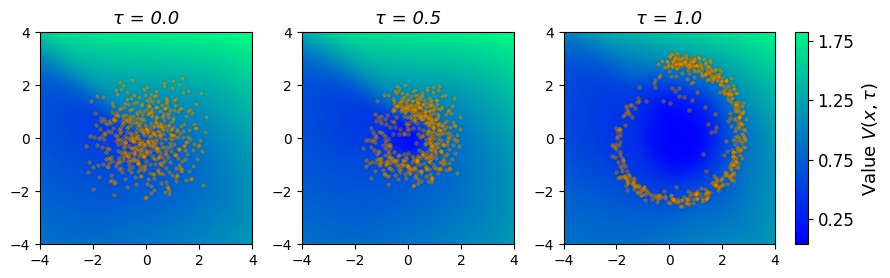

In [57]:
# ============================================================================
# REVERTED: SIMPLE VALUE LANDSCAPE + POLICY SAMPLE SCATTER (AS BEFORE)
# ============================================================================

import pickle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import gaussian_filter  # for smoothing landscape/gradients

DATASET_TYPE = "swissroll"

ALPHA_TO_PLOT = 0.5  # Change to desired alpha

weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac_inner/weights_alpha{ALPHA_TO_PLOT}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'

try:
    with open(weights_path, 'rb') as f:
        loaded_weights = pickle.load(f)
    fbrac_inner_flow_params = loaded_weights['flow_params']
    fbrac_inner_inner_critic_params = loaded_weights['inner_critic_params']
    print(f"Loaded FBRAC-Inner weights for alpha={ALPHA_TO_PLOT}")
except FileNotFoundError:
    print(f"Weights not found for alpha={ALPHA_TO_PLOT}")
    raise

resolution = 100
plot_range = 4.0
timesteps = [0.0, 0.5, 1.0]
SMOOTH_SIGMA = 0.0
N_POLICY_SAMPLES = 512
POLICY_SEED = np.random.randint(0, 1000000)

# ----- Grid for 2D visualization -----
xs = np.linspace(-plot_range, plot_range, resolution)
ys = np.linspace(-plot_range, plot_range, resolution)
X, Y = np.meshgrid(xs, ys)
positions = np.stack([X.flatten(), Y.flatten()], axis=1)
positions_tensor = jnp.asarray(positions)

fbrac_inner_V = {}      # value landscape for each t

def _flow_forward(params, x, t):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(params, xt)

def _inner_critic_forward(params, x, t, use_residual=False):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(params, xt, use_residual=use_residual).squeeze(-1)

for t_val in timesteps:
    t_tensor = jnp.full((positions_tensor.shape[0], 1), t_val)
    v = _inner_critic_forward(fbrac_inner_inner_critic_params, positions_tensor, t_tensor)
    V_np = np.array(v).reshape(X.shape)
    if SMOOTH_SIGMA > 0.0:
        V_np = gaussian_filter(V_np, sigma=SMOOTH_SIGMA, mode='nearest')
    fbrac_inner_V[t_val] = V_np

all_V = np.array([fbrac_inner_V[t] for t in timesteps])
vmin = np.min(all_V)
vmax = np.max(all_V)

# ----- Policy samples through flow -----
from scipy.stats import norm
init_num = N_POLICY_SAMPLES
rng = np.random.default_rng(POLICY_SEED)
probs = np.linspace(0.01, 0.99, init_num+2)[1:-1]
quantiles_1d = norm.ppf(probs)
xs_s = quantiles_1d[rng.choice(init_num, init_num, replace=False)]
ys_s = quantiles_1d[rng.choice(init_num, init_num, replace=False)]
particles = np.stack([xs_s, ys_s], axis=1)
radius = 3.5
r2 = np.sum(particles ** 2, axis=1)
mask = r2 < radius**2
particles_masked = particles.copy()
particles_masked[~mask] = np.nan
particles_curr = jnp.asarray(particles_masked)

particle_history = {}
N_steps = FLOW_STEPS
stored_timesteps = {t: None for t in timesteps}
for step in range(N_steps + 1):
    t_val = step / N_steps
    for t in timesteps:
        if stored_timesteps[t] is None or abs(t_val - t) < abs((stored_timesteps[t] or 0)/N_steps - t):
            stored_timesteps[t] = step
all_particle_states = []
current_x = jnp.asarray(particles_masked)
for step in range(N_steps + 1):
    if step > 0:
        t_prev = (step - 1) / N_steps
        t_tensor = jnp.full((current_x.shape[0], 1), t_prev)
        step_displacement = _flow_forward(fbrac_inner_flow_params, current_x, t_tensor) / N_steps
        nan_mask = jnp.isnan(current_x[:, 0]) | jnp.isnan(current_x[:, 1])
        next_x = current_x + step_displacement
        next_x = jnp.where(nan_mask[:, None], jnp.nan, next_x)
        current_x = next_x
    all_particle_states.append(np.array(current_x))
for t_req, idx in stored_timesteps.items():
    particle_history[t_req] = all_particle_states[idx]

# ---------- Plotting: Value landscape + samples ----------

# Plot size and layout as in @file_context_0: fig size=(2.5 * n_cols + 1.5, 4), with colorbar at right
n_cols = len(timesteps)
fig = plt.figure(figsize=(2.5 * n_cols + 1.5, 4))
import matplotlib.gridspec as gridspec
gs = gridspec.GridSpec(1, n_cols, width_ratios=[1]*(n_cols-1) + [1.15])
axes = []
ims = []
scs = []

for col, t_val in enumerate(timesteps):
    ax = fig.add_subplot(gs[0, col])
    axes.append(ax)
    im = ax.contourf(X, Y, fbrac_inner_V[t_val], levels=200, cmap='winter', vmin=vmin, vmax=vmax)
    ims.append(im)
    ax.set_title(f'τ = {t_val}', fontstyle='italic', fontsize=13)
    ax.set_aspect('equal')
    ax.set_xlim(-plot_range, plot_range)
    ax.set_ylim(-plot_range, plot_range)
    # Overlay policy samples
    p_pos = particle_history.get(t_val, None)
    if p_pos is not None:
        good = ~np.isnan(p_pos[:, 0]) & ~np.isnan(p_pos[:, 1])
        sc = ax.scatter(
            p_pos[good, 0], p_pos[good, 1],
            s=13, c='orange', label='Policy Samples', edgecolor='k', linewidth=0.3, alpha=0.3, zorder=3
        )
        scs.append(sc)
    else:
        ax.scatter([], [], s=13, c='red', label='Policy Samples', edgecolor='k', alpha=0.3)

axes = np.array(axes)

# Place colorbar axis on the right of the last Q subplot using axes_grid1
divider = make_axes_locatable(axes[0 if n_cols == 1 else n_cols - 1])
cax = divider.append_axes("right", size="6%", pad=0.2)
tick_range = 0.25

def _ticks_0p5_multiple_limited(vmin, vmax, max_ticks=6):
    start = np.ceil(vmin / tick_range) * tick_range
    end = np.floor(vmax / tick_range) * tick_range
    if end < start:
        return [np.round(vmin, 2), np.round(vmax, 2)]
    ticks = np.arange(start, end + 0.1 * tick_range, tick_range)
    ticks = np.round(ticks, 2)
    ticks = ticks[(ticks >= vmin - 1e-8) & (ticks <= vmax + 1e-8)]
    ticks = ticks.tolist()
    # Limit to max_ticks: choose evenly spaced from available, always include first and last
    if len(ticks) > max_ticks:
        ticks = [ticks[i] for i in range(len(ticks)) if i % 2 == 0]
    return ticks

cbar_ticks_0p5 = _ticks_0p5_multiple_limited(vmin, vmax, max_ticks=4)
# Attach colorbar only to the landscape row, last col
cbar = fig.colorbar(ims[-1], cax=cax, ticks=cbar_ticks_0p5)
cbar.set_label("Value $V(x, τ)$", fontsize=13)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/{DATASET_TYPE}/{DATASET_TYPE}_value_landscape.png',
           dpi=300, bbox_inches='tight')
plt.show()

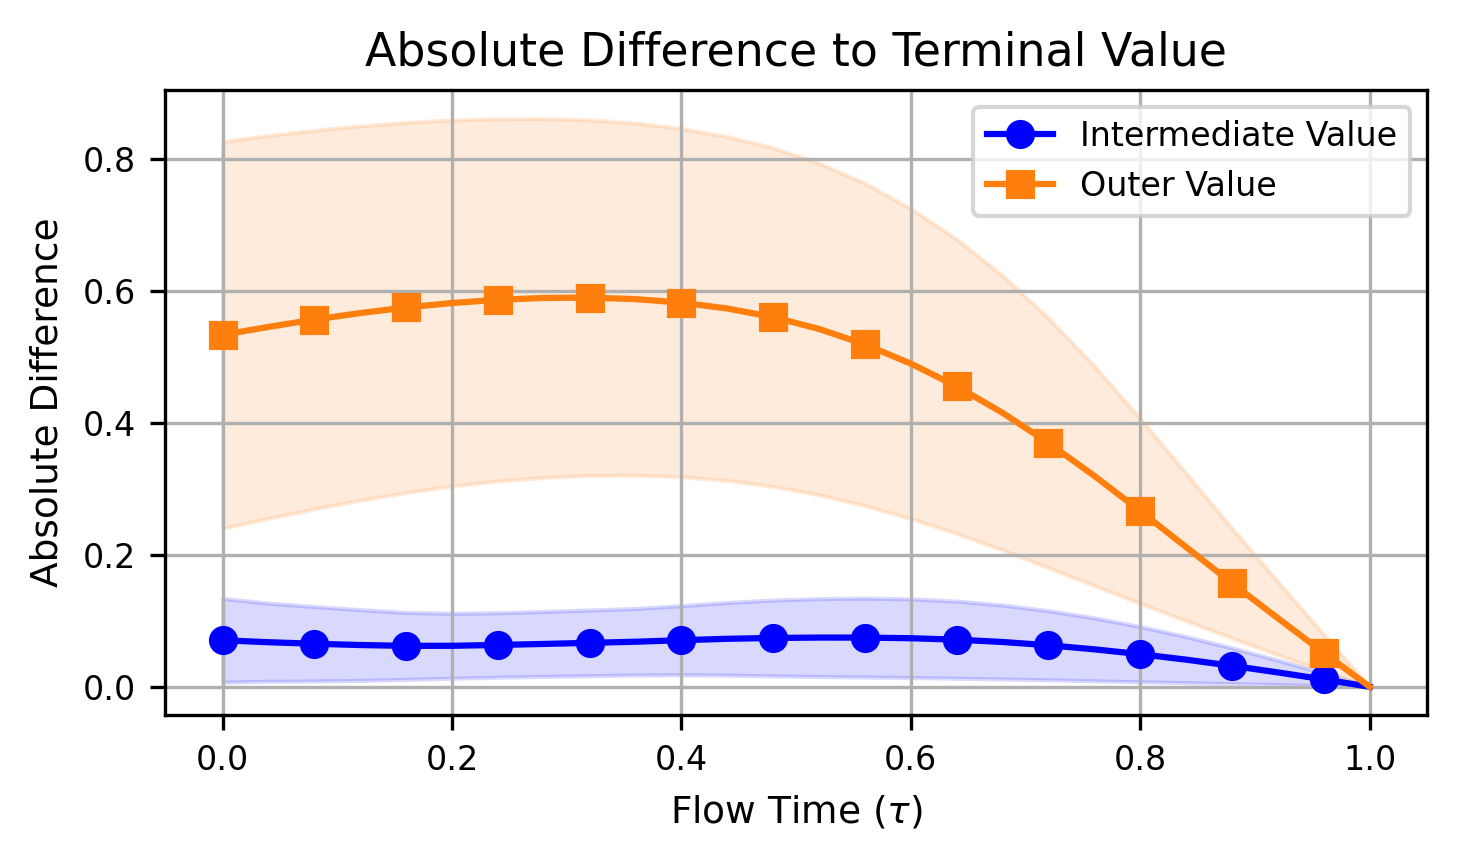

In [ ]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# 1. Helper for fbrac_inner V-value with time embedding
def _inner_critic_forward_plotting(params, x, t):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(params, xt).squeeze(-1)

# 2. Evaluation Setup
n_eval_traj = 512
key_traj = jax.random.PRNGKey(np.random.randint(0, 1000))
z_init = jax.random.normal(key_traj, (n_eval_traj, 2))

# 3. Collect fbrac_inner Trajectory Values
v_inner_history = []
x_inner = z_init
times = jnp.linspace(0.0, 1.0, FLOW_STEPS + 1)

for t_val in times:
    t_batch = jnp.full((n_eval_traj, 1), t_val)
    t_embed = fourier_time_embed(t_batch, embed_dim=16)
    v_val = _inner_critic_forward_plotting(fbrac_inner_inner_critic_params, x_inner, t_batch)
    v_inner_history.append(v_val)
    
    if t_val < 1.0:
        dt = 1.0 / FLOW_STEPS
        v_flow = flow_forward(fbrac_inner_flow_params, x_inner, t_batch)
        x_inner = x_inner + v_flow * dt
        x_inner = jnp.clip(x_inner, DOMAIN_MIN, DOMAIN_MAX)

v_inner_history = jnp.array(v_inner_history)
v_inner_err = jnp.abs(v_inner_history - v_inner_history[-1,:])
v_inner_err_mean = v_inner_err.mean(axis=-1)
v_inner_err_std = v_inner_err.std(axis=-1)

# 4. Collect fbrac_outer Trajectory Values (integrated Q)
v_outer_history = []
x_outer = z_init

t_ones = jnp.ones((n_eval_traj, 1))
for t_val in times:
    t_batch = jnp.full((n_eval_traj, 1), t_val)
    q_val = _inner_critic_forward_plotting(fbrac_inner_inner_critic_params, x_outer, t_ones)
    v_outer_history.append(q_val)
    
    if t_val < 1.0:
        dt = 1.0 / FLOW_STEPS
        v_flow = flow_forward(fbrac_inner_flow_params, x_outer, t_batch)
        x_outer = x_outer + v_flow * dt
        x_outer = jnp.clip(x_outer, DOMAIN_MIN, DOMAIN_MAX)

v_outer_history = jnp.array(v_outer_history)
v_outer_err = jnp.abs(v_outer_history - v_outer_history[-1,:])
v_outer_err_mean = v_outer_err.mean(axis=-1)
v_outer_err_std = v_outer_err.std(axis=-1)

# 5. Plotting
plt.figure(figsize=(5, 3), dpi=300)

# Set marker size
marker_size = 6  # You can adjust this as needed

# Half the number of markers: only plot on every other point
step = 2  # half the markers

plt.plot(
    times, 
    v_inner_err_mean, 
    label="Intermediate Value", 
    marker='o', 
    color='blue', 
    markevery=step,
    markersize=marker_size
)
plt.fill_between(
    times, 
    v_inner_err_mean - v_inner_err_std, 
    v_inner_err_mean + v_inner_err_std, 
    alpha=0.15, 
    color='blue'
)

plt.plot(
    times, 
    v_outer_err_mean, 
    label="Outer Value", 
    marker='s', 
    color='tab:orange',
    markevery=step,
    markersize=marker_size
)
plt.fill_between(
    times, 
    v_outer_err_mean - v_outer_err_std, 
    v_outer_err_mean + v_outer_err_std, 
    alpha=0.15,
    color='tab:orange'
)
plt.xlabel(r'Flow Time ($\tau$)', fontsize=9)
plt.ylabel("Absolute Difference", fontsize=9)
plt.title("Absolute Difference to Terminal Value", fontsize=10)
plt.tight_layout()
plt.legend(fontsize=8)
plt.grid(True)

# Set x and y ticks font size
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=8)
yticks = ax.get_yticks()
# if len(yticks) > 6:
#     # Only keep every other yticks label for fewer: len//2, always keep the first and last
#     keep_idx = [0] + list(range(1, len(yticks)-1, 2)) + [len(yticks)-1]
#     keep_idx = sorted(set(keep_idx))  # remove duplicates if any
#     ax.set_yticks([yticks[i] for i in keep_idx if i < len(yticks)])

plt.savefig('/mnt/nas/jaehyeok/fql/exp/value_difference_main.png', dpi=300)


Loaded FBRAC-Inner weights for alpha=0.5


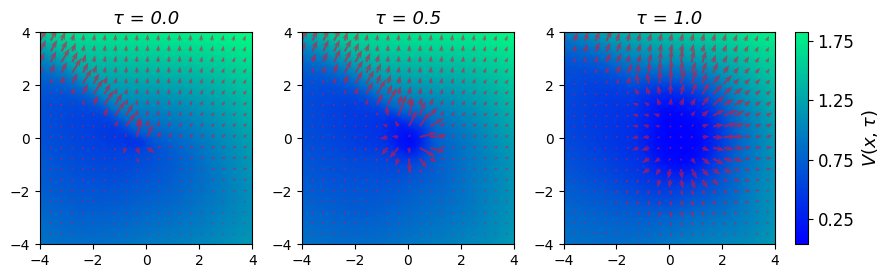

In [55]:
# ============================================================================
# PLOT FBRAC_INNER Q LANDSCAPE AND GRADIENT FIELD OVER FLOW TIMESTEPS
# ============================================================================

import pickle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import gaussian_filter
import matplotlib.gridspec as gridspec

DATASET_TYPE = "swissroll"

# Specify which alpha to visualize
ALPHA_TO_PLOT = 0.5  # Change this to the desired alpha value

# Load weights for the specific alpha
weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac_inner/weights_alpha{ALPHA_TO_PLOT}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'

try:
    with open(weights_path, 'rb') as f:
        loaded_weights = pickle.load(f)
    
    fbrac_inner_flow_params = loaded_weights['flow_params']
    fbrac_inner_inner_critic_params = loaded_weights['inner_critic_params']
    print(f"Loaded FBRAC-Inner weights for alpha={ALPHA_TO_PLOT}")
except FileNotFoundError:
    print(f"Weights not found for alpha={ALPHA_TO_PLOT}")
    raise

# Settings
resolution = 100
plot_range = 4.0
timesteps = [0.0, 0.5, 1.0]
SMOOTH_SIGMA = 0.0  # <-- Set smoothing kernel size (can increase for more smoothness, or set to 0 to disable)

# ============= STEP 1: Create grid and eval V landscape over time =============
xs = np.linspace(-plot_range, plot_range, resolution)
ys = np.linspace(-plot_range, plot_range, resolution)
X, Y = np.meshgrid(xs, ys)
positions = np.stack([X.flatten(), Y.flatten()], axis=1)
positions_tensor = jnp.asarray(positions)

fbrac_inner_V = {}

# --- Local forward functions as in @file_context_0
def _inner_critic_forward(params, x, t, use_residual=False):
    xt = jnp.concatenate([x, t], axis=-1)
    return apply_mlp(params, xt, use_residual=use_residual).squeeze(-1)

for t_val in timesteps:
    t_tensor = jnp.full((positions_tensor.shape[0], 1), t_val)
    
    # Value - use inner critic
    v = _inner_critic_forward(fbrac_inner_inner_critic_params, positions_tensor, t_tensor)
    V_np = np.array(v).reshape(X.shape)
    if SMOOTH_SIGMA > 0.0:
        V_np = gaussian_filter(V_np, sigma=SMOOTH_SIGMA, mode='nearest')
    fbrac_inner_V[t_val] = V_np

all_V = np.array([fbrac_inner_V[t] for t in timesteps])
vmin = np.min(all_V)
vmax = np.max(all_V)

# ======== STEP 2: Compute gradient (∇V) on grid for each t ===========

fbrac_inner_V_grads = {}

dx = xs[1] - xs[0]
dy = ys[1] - ys[0]

for t_val in timesteps:
    V_np = fbrac_inner_V[t_val]
    # Compute gradients in y (row, axis=0) and x (col, axis=1) directions
    dV_dy, dV_dx = np.gradient(V_np, dy, dx)
    # Gradient field is (dV/dx, dV/dy) at each (x, y)
    fbrac_inner_V_grads[t_val] = (dV_dx, dV_dy)

# ======== STEP 3: Plotting - Q landscape with gradient field ===========

def _nice_ticks(vmin, vmax, n=6):
    if np.allclose(vmin, vmax):
        return [float(vmin)]
    spacing = (vmax - vmin) / (n-1)
    ticks = [vmin + i*spacing for i in range(n)]
    return [np.round(tick, 2) for tick in ticks]
cbar_ticks = _nice_ticks(vmin, vmax)

n_cols = len(timesteps)
n_rows = 1  # Only landscape row
fig = plt.figure(figsize=(2.5 * n_cols + 1.5, 4))
gs = gridspec.GridSpec(1, n_cols, width_ratios=[1]*(n_cols-1) + [1.15])
axes = []
ims = []

for col, t_val in enumerate(timesteps):
    ax = fig.add_subplot(gs[0, col])
    axes.append(ax)
    im = ax.contourf(X, Y, fbrac_inner_V[t_val], levels=200, cmap='winter', vmin=vmin, vmax=vmax)
    ims.append(im)
    ax.set_title(f'τ = {t_val}', fontstyle='italic', fontsize=13)
    ax.set_aspect('equal')
    ax.set_xlim(-plot_range, plot_range)
    ax.set_ylim(-plot_range, plot_range)

    # Overlay gradient field (∇V)
    dV_dx, dV_dy = fbrac_inner_V_grads[t_val]
    # --- Reduce the density of the gradient field and scale vector length for improved visibility
    grad_skip = 5  # coarser, for improved visibility (was 5)
    skip = (slice(None, None, grad_skip), slice(None, None, grad_skip))
    # Scale up the gradient field by a factor of 2 for visualization

    scale_factor = 1.3
    ax.quiver(
        X[skip], Y[skip],
        scale_factor * dV_dx[skip], scale_factor * dV_dy[skip],
        color='crimson', angles='xy', scale_units='xy', scale=1.5,
        width=0.01,       # Increase this value for a thicker arrow body (shaft). Default is 0.005.
        headwidth=3, headlength=4, headaxislength=3, alpha=0.6
    )

axes = np.array(axes)

# Place colorbar axis on the right of the last Q subplot using axes_grid1
divider = make_axes_locatable(axes[0 if n_cols == 1 else n_cols - 1])
cax = divider.append_axes("right", size="6%", pad=0.2)
tick_range = 0.25

def _ticks_0p5_multiple_limited(vmin, vmax, max_ticks=6):
    start = np.ceil(vmin / tick_range) * tick_range
    end = np.floor(vmax / tick_range) * tick_range
    if end < start:
        return [np.round(vmin, 2), np.round(vmax, 2)]
    ticks = np.arange(start, end + 0.1 * tick_range, tick_range)
    ticks = np.round(ticks, 2)
    ticks = ticks[(ticks >= vmin - 1e-8) & (ticks <= vmax + 1e-8)]
    ticks = ticks.tolist()
    # Limit to max_ticks: choose evenly spaced from available, always include first and last
    if len(ticks) > max_ticks:
        ticks = [ticks[i] for i in range(len(ticks)) if i % 2 == 0]
    return ticks

cbar_ticks_0p5 = _ticks_0p5_multiple_limited(vmin, vmax, max_ticks=4)
# Attach colorbar only to the landscape row, last col
cbar = fig.colorbar(ims[-1], cax=cax, ticks=cbar_ticks_0p5)
cbar.set_label("$V(x, τ)$", fontsize=13)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig(f'/mnt/nas/jaehyeok/fql/exp/value_gradient_main.png',
            dpi=300, bbox_inches='tight')
plt.show()

### Main Toy 2-D Experiment Results

In [7]:
def load_full_results(SAVE_DIR, DATASET_TYPE, FLOW_STEPS, NUM_LAYERS, HIDDEN_DIM, N_DATA, EPOCHS, ALPHAS):

    fbrac_inner_results = []

    # Load all saved weights for all alphas - FBRAC-Inner (TVL)

    for ALPHA in ALPHAS:
        weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac_inner/weights_alpha{ALPHA}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'
        
        try:
            with open(weights_path, 'rb') as f:
                loaded_weights = pickle.load(f)
            
            flow_params = loaded_weights['flow_params']
            bc_policy_params = loaded_weights['bc_policy_params']
            fbrac_inner_results.append((ALPHA, flow_params, bc_policy_params))
            print(f"Loaded FBRAC-Inner weights for alpha={ALPHA}")
        except FileNotFoundError:
            print(f"FBRAC-Inner weights not found for alpha={ALPHA}, skipping...")

    print(f"Loaded {len(fbrac_inner_results)} FBRAC-Inner model(s)")

    # Load all saved weights for all alphas - FQL
    fql_results = []

    for ALPHA in ALPHAS:
        weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fql/weights_alpha{ALPHA}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'
        
        try:
            with open(weights_path, 'rb') as f:
                loaded_weights = pickle.load(f)
            
            policy_params = loaded_weights['policy_params']
            bc_policy_params = loaded_weights['bc_policy_params']
            fql_results.append((ALPHA, policy_params, bc_policy_params))
            print(f"Loaded FQL weights for alpha={ALPHA}")
        except FileNotFoundError:
            print(f"FQL weights not found for alpha={ALPHA}, skipping...")

    print(f"Loaded {len(fql_results)} FQL model(s)")

    # Load all saved weights for all alphas - FBRAC
    fbrac_results = []

    for ALPHA in ALPHAS:
        weights_path = f'{SAVE_DIR}/{DATASET_TYPE}/fbrac/weights_alpha{ALPHA}_flow{FLOW_STEPS}_layers{NUM_LAYERS}_hidden{HIDDEN_DIM}_data{N_DATA}_epochs{EPOCHS}.pkl'
        
        try:
            with open(weights_path, 'rb') as f:
                loaded_weights = pickle.load(f)
            
            flow_params = loaded_weights['flow_params']
            bc_policy_params = loaded_weights['bc_policy_params']
            fbrac_results.append((ALPHA, flow_params, bc_policy_params))
            print(f"Loaded FBRAC weights for alpha={ALPHA}")
        except FileNotFoundError:
            print(f"FBRAC weights not found for alpha={ALPHA}, skipping...")

    print(f"Loaded {len(fbrac_results)} FBRAC model(s)")

    # Sort results for plotting
    fbrac_inner_results_sorted = sorted(fbrac_inner_results, key=lambda x: x[0], reverse=True)
    fql_results_sorted = sorted(fql_results, key=lambda x: x[0], reverse=True)
    fbrac_results_sorted = sorted(fbrac_results, key=lambda x: x[0], reverse=True)

    return fbrac_inner_results_sorted, fql_results_sorted, fbrac_results_sorted

Loaded FBRAC-Inner weights for alpha=5.0
Loaded FBRAC-Inner weights for alpha=0.5
Loaded 2 FBRAC-Inner model(s)
Loaded FQL weights for alpha=5.0
Loaded FQL weights for alpha=0.5
Loaded 2 FQL model(s)
Loaded FBRAC weights for alpha=5.0
Loaded FBRAC weights for alpha=0.5
Loaded 2 FBRAC model(s)


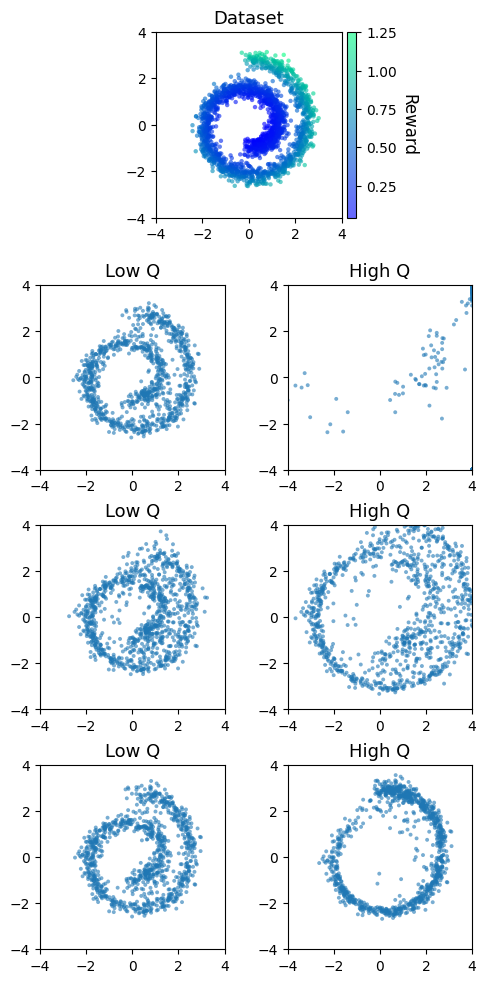

In [ ]:
SAVE_DIR="toy_experiment/activation_test"
DATASET_TYPE="swissroll"
FLOW_STEPS=25
NUM_LAYERS=4
HIDDEN_DIM=512
N_DATA=10000
EPOCHS=2100
ALPHAS=[5.0, 0.5]
titles= [ 'Low Q', 'High Q']
fbrac_inner_results_sorted, fql_results_sorted, fbrac_results_sorted = load_full_results(SAVE_DIR, DATASET_TYPE, FLOW_STEPS, NUM_LAYERS, HIDDEN_DIM, N_DATA, EPOCHS, ALPHAS)

NUM_EVALS=1024

# Check which results are available
has_fql = 'fql_results_sorted' in globals() and len(fql_results_sorted) > 0
has_fbrac = 'fbrac_results_sorted' in globals() and len(fbrac_results_sorted) > 0
has_tvl = 'fbrac_inner_results_sorted' in globals() and len(fbrac_inner_results_sorted) > 0

if not (has_fql or has_fbrac or has_tvl):
    print("No results available. Please run the training cells first.")
else:
    # Get the maximum number of alphas
    max_alphas = 0
    if has_fql: max_alphas = max(max_alphas, len(fql_results_sorted))
    if has_fbrac: max_alphas = max(max_alphas, len(fbrac_results_sorted))
    if has_tvl: max_alphas = max(max_alphas, len(fbrac_inner_results_sorted))
    
    # --- LAYOUT SETUP ---
    # We use a nested gridspec to decouple the Dataset row from the Method rows
    # height_ratios=[1, 3.2] gives roughly equal height per row (1 row vs 3 rows + padding)
    fig = plt.figure(figsize=(2.5 * max_alphas, 2.5 * 4))
    outer_gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3.2])
    
    # 1. TOP BLOCK: DATASET
    # We make a 1x3 grid for the top block: [Empty, Plot, Empty]
    # This ensures the plot is mathematic
    # ally centered in the middle column
    gs_top = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer_gs[0], width_ratios=[1, 2, 1])
    ax_dataset = fig.add_subplot(gs_top[0, 1])
    
    # 2. BOTTOM BLOCK: METHODS
    # Standard grid for the methods
    gs_bottom = gridspec.GridSpecFromSubplotSpec(3, max_alphas, subplot_spec=outer_gs[1], hspace=0.3)

    # --- PLOTTING DATASET ---
    z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))
    
    # Sample dataset
    np.random.seed(42)
    dataset_samples, dataset_rewards = sample_from_dataset(2000)
    dataset_rewards = dataset_rewards.flatten()

    sc = ax_dataset.scatter(dataset_samples[:, 0], dataset_samples[:, 1], 
                           c=dataset_rewards, cmap='winter', s=10, alpha=0.6, edgecolors='none')
    ax_dataset.set_title("Dataset", fontsize=13)
    ax_dataset.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    ax_dataset.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax_dataset.set_aspect('equal')
    
    # Robust Colorbar: Use make_axes_locatable to append axes without shrinking the main plot asymmetrically
    divider = make_axes_locatable(ax_dataset)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(sc, cax=cax)
    cbar.set_label('Reward', fontsize=12, rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=10)
    
    # --- PLOTTING METHODS ---
    method_rows = [fbrac_results_sorted, fql_results_sorted, fbrac_inner_results_sorted]
    row_labels = ["FBRAC", "FQL", "TVL"]  # Keep original labels
    
    for row_idx, method_results in enumerate(method_rows):
        has_method = len(method_results) > 0
        
        for col_idx in range(max_alphas):
            ax = fig.add_subplot(gs_bottom[row_idx, col_idx])
            
            # if row_idx == 0:
            ax.set_title(f'{titles[col_idx]}', fontsize=13)
            
            # Add Row Label on the left-most column
            # if col_idx == 0:
            #     ax.set_ylabel(row_labels[row_idx], fontsize=12, rotation=90, labelpad=18)

            if has_method and col_idx < len(method_results):
                alpha, params, _ = method_results[col_idx]
                
                # Inference logic
                if row_idx == 1: # FQL (One-step)
                    actions = np.array(onestep_forward(params, z_eval))
                else: # FBRAC or TVL (Flow)
                    if isinstance(params, tuple): params = params[0]
                    try:
                        actions = np.array(integrate_flow(params, z_eval, steps=FLOW_STEPS))
                    except:
                        actions = np.array(integrate_flow_with_time(params, z_eval, steps=FLOW_STEPS))
                
                ax.scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
                ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
                ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
                ax.set_aspect('equal')
            else:
                ax.axis('off')

    plt.tight_layout()
    
    # Optionally save the figure
    save_dir = f'{SAVE_DIR}/{DATASET_TYPE}'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f'{save_dir}/{DATASET_TYPE}_main.png',
                dpi=100, bbox_inches='tight')

In [274]:
SAVE_DIR="toy_experiment/activation_test"
FLOW_STEPS=25
NUM_LAYERS=4
HIDDEN_DIM=512
N_DATA=10000
ALPHAS=[5.0, 0.5]
titles= ['Low Q', 'High Q']
NUM_EVALS=1024

DATASETS = ["swissroll", "two_spirals"]
EPOCHS_DICT = {
    "swissroll": 2100,
    "two_spirals": 5100
}
method_names = ["FBRAC", "FQL", "TVL"]

# Load results for both datasets
all_results = {}
for DATASET_TYPE in DATASETS:
    EPOCHS = EPOCHS_DICT[DATASET_TYPE]
    fbrac_inner_results_sorted, fql_results_sorted, fbrac_results_sorted = load_full_results(
        SAVE_DIR, DATASET_TYPE, FLOW_STEPS, NUM_LAYERS, HIDDEN_DIM, N_DATA, EPOCHS, ALPHAS
    )
    all_results[DATASET_TYPE] = {
        'fbrac': fbrac_results_sorted,
        'fql': fql_results_sorted,
        'tvl': fbrac_inner_results_sorted
    }

# For each method, create a plot with both datasets
for method_idx, (method_key, method_name) in enumerate(zip(['fbrac', 'fql', 'tvl'], method_names)):
    # Check if method has results
    has_method = False
    for DATASET_TYPE in DATASETS:
        if len(all_results[DATASET_TYPE][method_key]) > 0:
            has_method = True
            break
    
    if not has_method:
        print(f"No results available for {method_name}")
        continue
    
    # Create figure: 1 row (method) × 4 columns (2 datasets × 2 alphas each)
    fig = plt.figure(figsize=(2.5 * 4, 2.5 * 1))
    gs = gridspec.GridSpec(1, 4)
    
    z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))
    
    col_idx = 0
    for DATASET_TYPE in DATASETS:
        method_results = all_results[DATASET_TYPE][method_key]
        has_method_data = len(method_results) > 0
        
        for alpha_idx in range(len(ALPHAS)):
            ax = fig.add_subplot(gs[0, col_idx])
            
            # Title: only alpha title
            ax.set_title(f'{titles[alpha_idx]}', fontsize=13)
            
            if has_method_data and alpha_idx < len(method_results):
                alpha, params, _ = method_results[alpha_idx]
                
                # Inference logic
                if method_idx == 1:  # FQL (One-step)
                    actions = np.array(onestep_forward(params, z_eval))
                else:  # FBRAC or TVL (Flow)
                    if isinstance(params, tuple): 
                        params = params[0]
                    try:
                        actions = np.array(integrate_flow(params, z_eval, steps=FLOW_STEPS))
                    except:
                        actions = np.array(integrate_flow_with_time(params, z_eval, steps=FLOW_STEPS))
                
                ax.scatter(actions[:, 0], actions[:, 1], s=8, alpha=0.6, edgecolors='none')
                ax.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
                ax.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
                ax.set_aspect('equal')
            else:
                ax.axis('off')
            
            col_idx += 1
    
    plt.tight_layout()
    
    # Save the figure
    save_dir = f'{SAVE_DIR}'
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f'{save_dir}/{method_name.lower()}_main.png',
                dpi=100, bbox_inches='tight')
    plt.close()
    print(f"Saved {method_name} comparison plot")

print("All method plots saved!")

Loaded FBRAC-Inner weights for alpha=5.0
Loaded FBRAC-Inner weights for alpha=0.5
Loaded 2 FBRAC-Inner model(s)
Loaded FQL weights for alpha=5.0
Loaded FQL weights for alpha=0.5
Loaded 2 FQL model(s)
Loaded FBRAC weights for alpha=5.0
Loaded FBRAC weights for alpha=0.5
Loaded 2 FBRAC model(s)
Loaded FBRAC-Inner weights for alpha=5.0
Loaded FBRAC-Inner weights for alpha=0.5
Loaded 2 FBRAC-Inner model(s)
Loaded FQL weights for alpha=5.0
Loaded FQL weights for alpha=0.5
Loaded 2 FQL model(s)
Loaded FBRAC weights for alpha=5.0
Loaded FBRAC weights for alpha=0.5
Loaded 2 FBRAC model(s)
Saved FBRAC comparison plot
Saved FQL comparison plot
Saved TVL comparison plot
All method plots saved!


In [275]:
SAVE_DIR="toy_experiment/activation_test"
FLOW_STEPS=25
NUM_LAYERS=4
HIDDEN_DIM=512
N_DATA=10000
ALPHAS=[5.0, 0.5]
titles= ['Low Q', 'High Q']
NUM_EVALS=1024

DATASETS = ["swissroll", "two_spirals"]
EPOCHS_DICT = {
    "swissroll": 2100,
    "two_spirals": 5100
}

# Create dataset row plot
fig = plt.figure(figsize=(2.5 * 4, 2.5 * 1))
# Use nested gridspec to center each dataset in 2 columns
outer_gs = gridspec.GridSpec(1, 4, wspace=0.1)

# Sample dataset for visualization
np.random.seed(42)
z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))

for dataset_idx, DATASET_TYPE in enumerate(DATASETS):
    # Each dataset gets 2 columns, centered within those columns
    # Swissroll: columns 0-1, Two_spirals: columns 2-3
    col_start = dataset_idx * 2
    col_end = col_start + 1
    
    # Create nested gridspec for centering: [empty, plot, empty] within 2 columns
    gs_dataset = gridspec.GridSpecFromSubplotSpec(
        1, 3, 
        subplot_spec=outer_gs[0, col_start:col_end+1], 
        width_ratios=[1, 2, 1]
    )
    ax_dataset = fig.add_subplot(gs_dataset[0, 1])
    
    # Sample dataset
    dataset_samples, dataset_rewards = sample_from_dataset(2000)
    dataset_rewards = dataset_rewards.flatten()
    
    sc = ax_dataset.scatter(
        dataset_samples[:, 0], dataset_samples[:, 1], 
        c=dataset_rewards, cmap='winter', s=10, alpha=0.6, edgecolors='none'
    )
    ax_dataset.set_title("Dataset", fontsize=13)
    ax_dataset.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    ax_dataset.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax_dataset.set_aspect('equal')
    
    # Colorbar directly to the right of the dataset plot
    divider = make_axes_locatable(ax_dataset)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(sc, cax=cax)
    cbar.set_label('Reward', fontsize=12, rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=10)

plt.tight_layout()

# Save the figure
save_dir = f'{SAVE_DIR}'
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f'{save_dir}/dataset_main.png',
            dpi=100, bbox_inches='tight')
plt.close()
print("Saved dataset row plot")

/tmp/ipykernel_1810230/3288597530.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved dataset row plot


In [287]:
SAVE_DIR="toy_experiment/activation_test"
FLOW_STEPS=25
NUM_LAYERS=4
HIDDEN_DIM=512
N_DATA=10000
ALPHAS=[5.0, 0.5]
titles= ['Low Q', 'High Q']
NUM_EVALS=1024

DATASETS = ["swissroll", "two_spirals"]
EPOCHS_DICT = {
    "swissroll": 2100,
    "two_spirals": 5100
}

# Create dataset row plot with indents and gap matching method plots
fig = plt.figure(figsize=(2.5 * 4, 2.5 * 1))
# Width ratios: [0.5 indent, 1.0 dataset1, 1.0 gap, 1.0 dataset2, 0.5 indent] = 4 total
# This matches the spacing of method plots (4 equal columns with wspace)
gs = gridspec.GridSpec(1, 5, width_ratios=[0.5, 1.3, 1.0, 1.3, 0.5])

# Sample dataset for visualization
np.random.seed(42)
z_eval = jrandom.normal(jrandom.PRNGKey(999), (NUM_EVALS, 2))

# Plot datasets at columns 1 and 3 (with gap column 2 in between)
dataset_cols = [1, 3]
for dataset_idx, DATASET_TYPE in enumerate(DATASETS):
    col = dataset_cols[dataset_idx]
    
    ax_dataset = fig.add_subplot(gs[0, col])
    
    # Sample dataset
    dataset_samples, dataset_rewards = sample_from_dataset(2000)
    dataset_rewards = dataset_rewards.flatten()
    
    sc = ax_dataset.scatter(
        dataset_samples[:, 0], dataset_samples[:, 1], 
        c=dataset_rewards, cmap='winter', s=10, alpha=0.6, edgecolors='none'
    )
    ax_dataset.set_xlim(DOMAIN_MIN, DOMAIN_MAX)
    ax_dataset.set_ylim(DOMAIN_MIN, DOMAIN_MAX)
    ax_dataset.set_aspect('equal')
    
    # Colorbar directly to the right of the dataset plot
    divider = make_axes_locatable(ax_dataset)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(sc, cax=cax)
    cbar.set_label('Reward', fontsize=12, rotation=270, labelpad=15)
    cbar.ax.tick_params(labelsize=10)

# Hide the indent and gap columns
fig.add_subplot(gs[0, 0]).axis('off')  # Left indent
fig.add_subplot(gs[0, 2]).axis('off')  # Gap column
fig.add_subplot(gs[0, 4]).axis('off')  # Right indent

plt.tight_layout()

# Save the figure
save_dir = f'{SAVE_DIR}'
os.makedirs(save_dir, exist_ok=True)
plt.savefig(f'{save_dir}/dataset_main.png',
            dpi=100, bbox_inches='tight')
plt.close()
print("Saved dataset row plot")

Saved dataset row plot
